# Graph ALMM

In [2]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls
from sklearn.decomposition import PCA

# Import functions from Chen et. al.
from graph_active_learning_functions import *

Temporarily trying to add error related plots feature

## GRSU

In [2]:
# Graph plotter

def graph_plotter(i, A_error, RMSE_plot, A_error_array, RMSE_array, title_0):
    x_iterations = [j for j in range(i)]

    plots_to_show = []
    if A_error:
        plots_to_show.append(("A Error (||A_new - A||)", A_error_array))
    if RMSE_plot:
        plots_to_show.append(("RMSE vs Ground Truth", RMSE_array))

    if plots_to_show:
        fig, axes = plt.subplots(1, len(plots_to_show), figsize=(6*len(plots_to_show), 5))
        if len(plots_to_show) == 1:
            axes = [axes]  # make it indexable even with just one subplot

        for ax, (title, data) in zip(axes, plots_to_show):
            ax.plot(x_iterations, data)
            ax.set_xlabel("Iterations")
            ax.set_ylabel(title)
            ax.set_title(title)

        fig.suptitle(title_0, fontsize=16)
        plt.tight_layout()
        plt.show()

    return
    

In [3]:
def algo_3_grsu_error(X, X_hat, A_hat, alpha, lam, gamma, rho, A_gt, max_iters=1000, eps=1e-3, k=50, A_error = False, RMSE_plot = False, title_0 = ""):
    """
    Executes the Graph-Regularized Semi-Supervised Unmixing (GRSU) model (Algorithm 3).

    Parameters:
    X (numpy.ndarray): Unlabeled data matrix (p, N).
    X_hat (numpy.ndarray): Labeled data matrix (p, M).
    A_hat (numpy.ndarray): Labeled abundance matrix / pseudo-labels (q, M).
    alpha (float): Weighting parameter for end-member estimation.
    lam (float): Graph regularization parameter (lambda).
    gamma (float): ADMM penalty parameter for S-T constraint.
    rho (float): ADMM penalty parameter for A-B constraint.
    max_iters (int): Maximum number of ADMM iterations.
    eps (float): Error tolerance for convergence.
    k (int): Number of nearest neighbors for graph construction.

    Returns:
    A_GRSU (numpy.ndarray): Final estimated abundance map (q, N).
    S_GRSU (numpy.ndarray): Final estimated end-member spectrum matrix (p, q).
    """
    p, N = X.shape
    q, M = A_hat.shape
    A_error_array = []
    RMSE_array = []


    # --- 1. Graph Construction & Laplacian Partitioning ---
    X_tilde = np.concatenate((X_hat, X), axis=1)
    G, W = build_custom_knn_graph(X_tilde.T, K=k)

    labeled_indices = np.arange(M)
    L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, labeled_indices)

    # --- 2. Initialization via GLU (Algorithm 2) ---
    A, S = algo_2_glu(X, X_hat, A_hat, alpha, k=k)

    # Initialize ADMM auxiliary and dual variables
    B = np.copy(A)
    B_bar = np.zeros((q, N))
    T_bar = np.zeros((p, q))

    # Pre-compute constants that do not change during iterations
    I_q = np.eye(q)
    I_N_sparse = sps.eye(N, format='csr')

    # Terms in T's update
    X_hat_A_hat_T_alpha2 = (alpha**2) * (X_hat @ A_hat.T)
    A_hat_A_hat_T_alpha2 = (alpha**2) * (A_hat @ A_hat.T)

    # Terms in B's update
    L_B_system = L_uu + (rho / lam) * I_N_sparse
    L_lu_T_A_hat_T = L_lu.T @ A_hat.T # Shape: (N, q)

    Err = 1.0
    i = 0

    # --- 3. ADMM Iteration Loop ---
    while i < max_iters and Err > eps:

        # a) T subproblem update
        term1_T = (X @ A.T) + X_hat_A_hat_T_alpha2 + gamma * (S + T_bar)
        term2_T = (A @ A.T) + A_hat_A_hat_T_alpha2 + gamma * I_q
        T = term1_T @ np.linalg.inv(term2_T)

        # b) S subproblem update
        S_new = np.maximum(T - T_bar, 0)

        # c) A subproblem update
        term1_A = np.linalg.inv((S_new.T @ S_new) + rho * I_q)
        term2_A = (S_new.T @ X) + rho * (B - B_bar)
        A_unproj = term1_A @ term2_A
        A_new = project_onto_simplex(A_unproj)

        # d) B subproblem update (Graph Regularized Laplace Learning)
        # We solve the transposed system: L_B_system * B^T = RHS_B
        RHS_B = -L_lu_T_A_hat_T + (rho / lam) * (A_new.T + B_bar.T)
        B_new_T = np.zeros((N, q))

        for j in range(q):
            B_new_T[:, j], _ = spla.cg(L_B_system, RHS_B[:, j])
        B_new = B_new_T.T

        # e) Update dual variables
        B_bar_new = B_bar + (A_new - B_new)
        T_bar_new = T_bar + (S_new - T)

        # f) Calculate convergence error
        # Protect against division by zero in the denominator
        norm_S = np.linalg.norm(S, 'fro')
        norm_A = np.linalg.norm(A, 'fro')

        err_S = np.linalg.norm(S_new - S, 'fro') / norm_S if norm_S > 0 else 0
        err_A = np.linalg.norm(A_new - A, 'fro') / norm_A if norm_A > 0 else 0

        Err = max(err_S, err_A)

        # g) Advance state for next iteration
        
        # Calculate error
        if A_error:
            A_error_array.append(np.linalg.norm(A_new - A))
        if RMSE_plot:
            RMSE_array.append(RMSE(A, A_gt))

        S = S_new
        A = A_new
        B = B_new
        B_bar = B_bar_new
        T_bar = T_bar_new

        i += 1

    # Plot
    graph_plotter(i, A_error, RMSE_plot, A_error_array, RMSE_array, title_0)


    return A, S

In [4]:
def run_unmixing_pipeline_example_grsu(X, A_gt, S_gt, N, iters, alpha = 10.0, lam = 1.0, gamma = 1.0, rho = 1.0, m_0 = 2, print_bool = True, OH_labels = True, GRSU_bool = True, A_error = False, RMSE_plot = False, title_0 = ""):
    # ==========================================
    # Phase 0: Load Data (Mocking Jasper Ridge)
    # ==========================================
    #print("Loading data...")
    #N = 10000  # Number of pixels (e.g., 100x100 image)
    #p = 198    # Number of spectral bands [cite: 286]
    #q = 4      # Number of latent end-members (Tree, Water, Dirt, Road) [cite: 287, 288]

    # Mock full hyperspectral image X: shape (p, N)
    #X = np.random.rand(p, N, seed=42)

    # Mock ground-truth abundance map (only used to simulate human labeling)
    #A_gt = np.random.dirichlet(np.ones(q), size=N, seed=42).T

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================
    if print_bool:
        print("Building initial graph for Active Learning...")
    # Scikit-learn expects (samples, features), so we pass X.T
    # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
    G, W = build_custom_knn_graph(X.T, K=int(N*0.005))

    if print_bool:
        print("Running Active Learning...")
    # Start with 1 random pixel per material (m=4), sample up to 0.4% of total pixels (M=40) [cite: 323]
    # num_eigs = 0.5% of the pixels (equal to K)?
    labeled_indices = algo_1_active_learning(X, W, m_initial=m_0, M_total=int(0.004*N), num_eigs=int(N*0.005))

    # ==========================================
    # Phase 2: Extract Training Data
    # ==========================================
    if print_bool:
        print("Extracting training data and generating pseudo-labels...")
    # Extract the spectral signatures for the selected pixels
    X_hat = X[:, labeled_indices]

    # Extract ground-truth abundances and convert to One-Hot pseudo-labels [cite: 321, 322]
    A_hat_exact = A_gt[:, labeled_indices]
    A_hat_OH = generate_one_hot_labels(A_hat_exact)

    # Pick between Exact or OH labels
    if OH_labels:
        A_hat_test = A_hat_OH
        label_title = "OH"
    else:
        A_hat_test = A_hat_exact
        label_title = "Exact"

    # ==========================================
    # Phase 3: Semi-Supervised Unmixing
    # ==========================================
    if print_bool and GRSU_bool:
        print(f"Running GRSU (and GLU) Unmixing on {label_title}...")
    elif print_bool:
         print(f"Running GLU Unmixing on {label_title}...")

    # Hyperparameters based on the Jasper Ridge dataset in Table II [cite: 339, 340]
    # alpha = 10.0
    # lam = 1.0
    # gamma = 1.0
    # rho = 1.0

    # Note: The paper mentions an overlap between X_hat and X, but updates
    # the abundance map for all pixels in X anyway.

    # If we are only running GLU
    if not GRSU_bool:
        A_final, S_final = algo_2_glu(X, X_hat, A_hat_test, alpha, k=int(N*0.005))
    else:
        A_final, S_final = algo_3_grsu_error(
            X=X,
            X_hat=X_hat,
            A_hat=A_hat_test,
            alpha=alpha,
            lam=lam,
            gamma=gamma,
            rho=rho,
            max_iters=iters,
            A_gt = A_gt,
            eps=1e-3,
            k=int(N*0.005),
            A_error = A_error,
            RMSE_plot = RMSE_plot,
            title_0 = title_0
        )

    # Calculate RMSE and SAD
    A_rmse = RMSE(A_final, A_gt)
    S_sad = SAD(S_final, S_gt)

    if print_bool:
        print("Pipeline Complete!\n")
        print(f"Final Abundance Map Shape: {A_final.shape}")
        print(f"Final End-member Matrix Shape: {S_final.shape}")
        print(f"Final Abundance RMSE: {A_rmse}")
        print(f"Final Endmember SAD: {S_sad}")

    return A_final, S_final, A_rmse, S_sad

## ALMM

In [5]:
def algo_2_almm_optimized_error(X, S, A_gt, alpha, beta, gamma, eta, maxIter, A_error = False, RMSE_plot = False, title_0 = ""):
    """
    Optimized ALMM-Based SVDL.
    Note: Requires passing A_initial (from SCLSU) as an argument since 
    SCLSU is not defined in the scope of this snippet.
    """
    A_initial = SCLSU(X, S)
    p, N = X.shape
    p, q = S.shape
    L = int(p / 2)
    A_error_array = []
    RMSE_array = []

    # 1. Precompute loop-invariant matrices
    StS = S.T @ S
    StX = S.T @ X
    gamma_SSt = gamma * (S @ S.T)

    # Initialize standard variables
    G = np.zeros((q, N))
    H = np.zeros((q, N))
    M = np.zeros((q, N))
    B = np.zeros((L, N))

    # 2. Track N x N diagonal matrices as 1D vectors to save O(N^2) memory
    t_diag = np.ones(N)       # Equivalent to np.eye(N)
    delta_diag = np.zeros(N)  # Equivalent to np.zeros((N, N))
    u_diag = np.zeros(N)      # Equivalent to np.zeros((N, N))

    Lambda = np.zeros((q, N)) 
    Upsilon = np.zeros((q, N)) 
    Omega = np.zeros((q, N)) 

    Q = np.zeros((p, L)) 
    Pi = np.zeros((p, L)) 

    A = np.copy(A_initial)

    # Generate random orthogonal matrix for E
    np.random.seed(42)
    random_matrix = np.random.randn(p, L)
    E, _ = np.linalg.qr(random_matrix)

    # Initialize scalars
    t = 0
    xi = 1e-3
    xi_max = 1e6
    rho = 1.5
    epsilon = 1e-6
    converged = False

    # Identity matrices for subproblems (sizes q, L, p only!)
    I_q = np.eye(q)
    I_L = np.eye(L)
    I_p = np.eye(p)

    while (not converged) and t < maxIter:
        
        # M subproblem (solve instead of inv)
        # S.T @ E @ B evaluated as (S.T @ E) @ B for faster multiplication
        term2_M = StX - (S.T @ E) @ B + (xi * (A * t_diag)) - Omega
        M_new = np.linalg.solve(StS + xi * I_q, term2_M)

        # B subproblem
        term2_B = (E.T @ X) - (E.T @ S) @ M_new
        B_new = np.linalg.solve((E.T @ E) + beta * I_L, term2_B)

        # A subproblem
        # Multiplication by diagonal matrix T is just broadcasting: * t_diag
        term1_A = (xi * G) + Lambda + (xi * H) + Upsilon + (Omega * t_diag) + (xi * M_new * t_diag)
        
        # term2_A was purely diagonal, so we just divide by the diagonal values!
        diag_inv = 1.0 / (xi * (t_diag ** 2) + 2 * xi)
        A_new = term1_A * diag_inv
        A_new = A_new / (A_new.sum(axis=0, keepdims=True) + 1e-10)

        # T subproblem (Woodbury Matrix Identity to avoid N x N operations)
        Y = xi * M_new + Omega
        A_At = A_new @ A_new.T
        
        # K = (I_q + A A^T)^{-1}. Since q is small (e.g. 10), this is instant.
        K = np.linalg.solve(I_q + A_At, I_q) 
        
        # Calculate exactly the diagonal components needed
        Z = Y - (K @ A_At) @ Y
        diag_At_Z = np.sum(A_new * Z, axis=0) # Fast way to get diag of A^T Z
        diag_A_K_A = np.sum(A_new * (K @ A_new), axis=0)
        
        D = xi * u_diag + delta_diag
        T_new_diag = (1.0 / xi) * diag_At_Z + (1.0 / xi) * D * (1.0 - diag_A_K_A)

        # E subproblem (Right-side solve using Transpose)
        term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q) + Pi
        term2_E_inv = (B_new @ B_new.T) + xi * I_L
        E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # Q subproblem
        term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        term2_Q = (eta * Q) + (xi * E_new) - Pi
        Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # G, H, U subproblems
        term1_G = np.maximum(0, np.abs(A_new - (Lambda / xi)) - (alpha / xi))
        term2_G = np.sign(A_new - (Lambda / xi))
        G_new = term1_G * term2_G 
        H_new = np.maximum(0, A_new - (Upsilon / xi))
        U_new_diag = np.maximum(0, T_new_diag - (delta_diag / xi))

        # AT subproblem 
        AT_new = A_new * T_new_diag

        # Update Lagrange multipliers
        Lambda_new = Lambda + xi * (G_new - A_new)
        Upsilon_new = Upsilon + xi * (H_new - A_new)
        Omega_new = Omega + xi * (M_new - AT_new)
        Pi_new = Pi + xi * (Q_new - E_new)
        delta_diag_new = delta_diag + xi * (U_new_diag - T_new_diag)

        xi_new = min(rho * xi, xi_max)

        # Check convergence conditions
        if ((np.linalg.norm(G_new - A_new) < epsilon) and 
            (np.linalg.norm(H_new - A_new) < epsilon) and
            (np.linalg.norm(M_new - AT_new) < epsilon) and
            (np.linalg.norm(Q_new - E_new) < epsilon) and 
            (np.linalg.norm(U_new_diag - T_new_diag) < epsilon) and
            (np.linalg.norm(E_new - E) < epsilon)):

            converged = True
        else:
            t += 1

            # Calculate error
            if A_error:
                A_error_array.append(np.linalg.norm(A_new - A))
            if RMSE_plot:
                # Check for labeling issues
                corr = np.corrcoef(A[0], A_gt[0])[0, 1]
                if corr < 0:
                    A_f_corrected = 1 - A
                else:
                    A_f_corrected = A

                rmse = RMSE(A_f_corrected, A_gt)  # Calculate RMSE
                RMSE_array.append(rmse)

            M = M_new
            B = B_new
            A = A_new
            t_diag = T_new_diag
            E = E_new
            Q = Q_new
            G = G_new
            H = H_new
            u_diag = U_new_diag

            Lambda = Lambda_new
            Upsilon = Upsilon_new
            Omega = Omega_new
            Pi = Pi_new
            delta_diag = delta_diag_new
            xi = xi_new

    # Reconstruct the N x N diagonal matrix T at the very end to match expected output signature
    T_final = np.diag(t_diag)

    # Plot
    graph_plotter(t, A_error, RMSE_plot, A_error_array, RMSE_array, title_0)
    
    return E, A, T_final, B

## Graph ALMM

In [6]:
def algo_2_graph_almm_optimized_error(X, A_0, S, alpha, beta, gamma, eta, maxIter, xi_0, L_uu, L_lu_T_A_hat_T, labeled_indices, A_error, RMSE_plot, A_gt, title_0):
    """
    Optimized ALMM-Based SVDL.
    Note: Requires passing A_initial (from SCLSU) as an argument since 
    SCLSU is not defined in the scope of this snippet.
    """
    p, N = X.shape
    p, q = S.shape
    L = int(p / 2)
    A_error_array = []
    RMSE_array = []

    #A_0 = SCLSU(X, S)
    #print("Number of labeled points:", len(labeled_indices))

    # 1. Precompute loop-invariant matrices
    StS = S.T @ S
    StX = S.T @ X
    gamma_SSt = gamma * (S @ S.T)

    # Initialize standard variables
    G = np.zeros((q, N))
    H = np.zeros((q, N))
    M = np.zeros((q, N))
    B = np.zeros((L, N))

    # 2. Track N x N diagonal matrices as 1D vectors to save O(N^2) memory
    t_diag = np.ones(N)       # Equivalent to np.eye(N)
    delta_diag = np.zeros(N)  # Equivalent to np.zeros((N, N))
    u_diag = np.zeros(N)      # Equivalent to np.zeros((N, N))

    Lambda = np.zeros((q, N)) 
    Upsilon = np.zeros((q, N)) 
    Omega = np.zeros((q, N)) 

    Q = np.zeros((p, L)) 
    Pi = np.zeros((p, L)) 

    A = np.copy(A_0)

    # Generate random orthogonal matrix for E
    np.random.seed(42)
    # random_matrix = np.random.randn(p, L)
    # E, _ = np.linalg.qr(random_matrix)

    # E = S - vca(X)
    Ae, _, _ = vca(X, R = q)
    diff = S - Ae


    # Pad with random columns to reach L total, then orthogonalize via QR
    pad = np.random.randn(p, L - diff.shape[1])
    E_init_raw = np.hstack([diff, pad])   # shape (p, L)

    E, _ = np.linalg.qr(E_init_raw)       # (p, L), orthonormal columns, but "seeded" by your real diff


    # Initialize scalars
    t = 0
    xi = xi_0 # originally 1e-3
    xi_max = 1e6
    rho = 1.5
    epsilon = 1e-6
    converged = False

    # Identity matrices for subproblems (sizes q, L, p only!)
    I_q = np.eye(q)
    I_L = np.eye(L)
    I_p = np.eye(p)

    # Derive unlabeled indices from labeled_indices (test)
    all_indices = np.arange(N)
    unlabeled_indices = np.setdiff1d(all_indices, labeled_indices)
    N_unlabeled = len(unlabeled_indices)  # should match L_uu.shape[0]

    while (not converged) and t < maxIter:
        
        # M subproblem (solve instead of inv)
        # S.T @ E @ B evaluated as (S.T @ E) @ B for faster multiplication
        term2_M = StX - (S.T @ E) @ B + (xi * (A * t_diag)) - Omega
        M_new = np.linalg.solve(StS + xi * I_q, term2_M)

        # B subproblem
        term2_B = (E.T @ X) - (E.T @ S) @ M_new
        B_new = np.linalg.solve((E.T @ E) + beta * I_L, term2_B)

        # A subproblem
        # Multiplication by diagonal matrix T is just broadcasting: * t_diag
        term1_A = ((xi* 1) * G) + Lambda + ((xi *2)* H) + Upsilon + (Omega * t_diag) + (xi * M_new * t_diag)
        
        # term2_A was purely diagonal, so we just divide by the diagonal values!
        diag_inv = 1.0 / (xi * (t_diag ** 2) + 2 * xi)
        A_new_unproj = term1_A * diag_inv
        A_new_unproj = A_new_unproj / (A_new_unproj.sum(axis=0, keepdims=True) + 1e-10)
        A_new = project_onto_simplex(A_new_unproj) # Project onto the simplex for nonnegativity

        # T subproblem (Woodbury Matrix Identity to avoid N x N operations)
        Y = xi * M_new + Omega
        A_At = A_new @ A_new.T
        
        # K = (I_q + A A^T)^{-1}. Since q is small (e.g. 10), this is instant.
        K = np.linalg.solve(I_q + A_At, I_q) 
        
        # Calculate exactly the diagonal components needed
        Z = Y - (K @ A_At) @ Y
        diag_At_Z = np.sum(A_new * Z, axis=0) # Fast way to get diag of A^T Z
        diag_A_K_A = np.sum(A_new * (K @ A_new), axis=0)
        
        D = xi * u_diag + delta_diag
        T_new_diag = (1.0 / xi) * diag_At_Z + (1.0 / xi) * D * (1.0 - diag_A_K_A)

        # # E subproblem (Right-side solve using Transpose)
        # term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q) + Pi
        # term2_E_inv = (B_new @ B_new.T) + xi * I_L
        # E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # # Q subproblem
        # term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        # term2_Q = (eta * Q) + (xi * E_new) - Pi
        # Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # Q subproblem
        term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        term2_Q = (eta * Q) + (xi * E) - Pi
        Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # E subproblem (Right-side solve using Transpose)
        term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q_new) + Pi
        term2_E_inv = (B_new @ B_new.T) + xi * I_L
        E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # G, H, U subproblems
        # term1_G = np.maximum(0, np.abs(A_new - (Lambda / xi)) - (alpha / xi))
        # term2_G = np.sign(A_new - (Lambda / xi))
        # G_new = term1_G * term2_G 

        Z_0 = A_new - (Lambda / xi)
        G_new = half_threshold(Z_0, alpha, xi)

        # Replacing G update with B

        # # Terms in B's update (replaced rho / lam with xi for now)
        # I_N_sparse = sps.eye(N, format='csr')
        # L_B_system = L_uu + (xi) * I_N_sparse
        # #L_lu_T_A_hat_T = L_lu.T @ A_hat.T # Shape: (N, q)

        # RHS_G = -L_lu_T_A_hat_T + (xi) * A_new.T + Lambda.T
        # G_new_T = np.zeros((N, q))

        # for j in range(q):
        #     G_new_T[:, j], _ = spla.cg(L_B_system, RHS_G[:, j])
        # G_new = G_new_T.T


        # H subproblem — solve only on unlabeled portion
        I_N_unlabeled_sparse = sps.eye(N_unlabeled, format='csr')
        L_B_system = L_uu + xi * I_N_unlabeled_sparse

        # Only take unlabeled columns of A_new and Lambda for the RHS
        A_new_unlabeled = A_new[:, unlabeled_indices]      # shape (q, N_unlabeled)
        Lambda_unlabeled = Lambda[:, unlabeled_indices]     # shape (q, N_unlabeled)

        RHS_G = -L_lu_T_A_hat_T + xi * A_new_unlabeled.T + Lambda_unlabeled.T  # (N_unlabeled, q)
        H_unlabeled_T = np.zeros((N_unlabeled, q))

        for j in range(q):
            H_unlabeled_T[:, j], _ = spla.cg(L_B_system, RHS_G[:, j])

        
        H_unlabeled = H_unlabeled_T.T  # (q, N_unlabeled)

        # Reassemble full-size H: labeled portion anchored to A_new, unlabeled portion from graph solve
        H_new = np.zeros((q, N))
        H_new[:, labeled_indices] = A_new[:, labeled_indices]
        H_new[:, unlabeled_indices] = H_unlabeled
        
        #H_new = np.maximum(0, A_new - (Upsilon / xi)) (temporarily disable)

        U_new_diag = np.maximum(0, T_new_diag - (delta_diag / xi))
        

        # AT subproblem 
        AT_new = A_new * T_new_diag

        # Update Lagrange multipliers
        Lambda_new = Lambda + xi * (G_new - A_new)
        Upsilon_new = Upsilon + xi * (H_new - A_new)
        Omega_new = Omega + xi * (M_new - AT_new)
        Pi_new = Pi + xi * (Q_new - E_new)
        delta_diag_new = delta_diag + xi * (U_new_diag - T_new_diag)

        xi_new = min(rho * xi, xi_max)

        # Check convergence conditions
        if ((np.linalg.norm(G_new - A_new) < epsilon) and 
            (np.linalg.norm(H_new - A_new) < epsilon) and
            (np.linalg.norm(M_new - AT_new) < epsilon) and
            (np.linalg.norm(Q_new - E_new) < epsilon) and 
            (np.linalg.norm(U_new_diag - T_new_diag) < epsilon) and
            (np.linalg.norm(E_new - E) < epsilon)):

            converged = True
        else:
            t += 1

            # Calculate error
            if A_error:
                A_error_array.append(np.linalg.norm(A_new - A))
            if RMSE_plot:
                # Check for labeling issues
                corr = np.corrcoef(A[0], A_gt[0])[0, 1]
                if corr < 0:
                    A_f_corrected = 1 - A
                else:
                    A_f_corrected = A

                rmse = RMSE(A_f_corrected, A_gt)  # Calculate RMSE
                RMSE_array.append(rmse)

            M = M_new
            B = B_new
            A = A_new
            t_diag = T_new_diag
            E = E_new
            Q = Q_new
            G = G_new
            H = H_new
            u_diag = U_new_diag

            Lambda = Lambda_new
            Upsilon = Upsilon_new
            Omega = Omega_new
            Pi = Pi_new
            delta_diag = delta_diag_new
            xi = xi_new

    # Reconstruct the N x N diagonal matrix T at the very end to match expected output signature
    T_final = np.diag(t_diag)

    # Plot
    graph_plotter(t, A_error, RMSE_plot, A_error_array, RMSE_array, title_0)
    
    return E, A, T_final, B

In [7]:
def run_unmixing_pipeline_example_graph_almm(X, A_gt, S_gt, N, alpha, beta, gamma, eta, maxIter, M_total_0, m_0 = 2, xi_0 = 1e-3, OH_labels = True, print_bool = True, A_error = False, RMSE_plot = False, title_0 = ""):

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================

    if print_bool:
        print("Building initial graph for Active Learning...")
    # Scikit-learn expects (samples, features), so we pass X.T
    # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
    G, W = build_custom_knn_graph(X.T, K=int(N*0.005))

    if print_bool:
        print("Running Active Learning...")
    # Start with 1 random pixel per material (m=4), sample up to 0.4% of total pixels (M=40) [cite: 323]
    # num_eigs = 0.5% of the pixels (equal to K)?
    #  M_total_0 = int(0.004*N) is the default
    labeled_indices = algo_1_active_learning(X, W, m_initial=m_0, M_total=M_total_0, num_eigs=int(N*0.005))

    # ==========================================
    # Phase 2: Extract Training Data
    # ==========================================
    if print_bool:
        print("Extracting training data and generating pseudo-labels...")
    # Extract the spectral signatures for the selected pixels
    X_hat = X[:, labeled_indices]

    # Extract ground-truth abundances and convert to One-Hot pseudo-labels [cite: 321, 322] or exact labels
    A_hat_exact = A_gt[:, labeled_indices]
    L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, labeled_indices)

    if OH_labels:
        A_hat_OH = generate_one_hot_labels(A_hat_exact)
        L_lu_T_A_hat_T = L_lu.T @ A_hat_OH.T
        label_title = "OH"
    else:
        L_lu_T_A_hat_T = L_lu.T @ A_hat_exact.T
        label_title = "Exact"

    # ==========================================
    # Phase 3: Semi-Supervised Unmixing
    # ==========================================
    if print_bool:
        print(f"Running ALMM (and GLU) Unmixing on {label_title}...")

    # Note: The paper mentions an overlap between X_hat and X, but updates
    # the abundance map for all pixels in X anyway.

    if OH_labels:
        A_GLU, S_GLU = algo_2_glu(X, X_hat, A_hat_OH, alpha, k=int(N*0.005))
    else:
        A_GLU, S_GLU = algo_2_glu(X, X_hat, A_hat_exact, alpha, k=int(N*0.005))

    # The second condition number is a lot worse than the first
    # print("Condition number of S_gt_chem.T @ S_gt_chem:", np.linalg.cond(S_gt_chem.T @ S_gt_chem))
    # print("Condition number of S_GLU.T @ S_GLU:", np.linalg.cond(S_GLU.T @ S_GLU))

    E_final, A_final, T_final, B_final = algo_2_graph_almm_optimized_error(
        X, A_GLU, S_GLU, alpha = alpha, 
        beta = beta, gamma = gamma, eta = eta, 
        maxIter = maxIter, xi_0 = xi_0, 
        L_uu = L_uu, L_lu_T_A_hat_T = L_lu_T_A_hat_T, labeled_indices = labeled_indices,
        A_error = A_error, RMSE_plot = RMSE_plot, A_gt = A_gt, title_0 = title_0)

    # Calculate RMSE and SAD

    # Check for labeling issues
    corr = np.corrcoef(A_final[0], A_gt[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_final
    else:
        A_f_corrected = A_final

    A_rmse = RMSE(A_f_corrected, A_gt)
    S_sad = SAD(S_GLU, S_gt)

    if print_bool:
        print("Pipeline Complete!\n")
        print(f"Final Abundance Map Shape: {A_final.shape}")
        print(f"Final End-member Matrix Shape: {S_GLU.shape}")
        print(f"Final Abundance RMSE: {A_rmse}")
        print(f"Final Endmember SAD: {S_sad}")

    return A_final, S_GLU, A_rmse, S_sad

# Miscellaneous Functions

## Load data

In [61]:
def load_data(name, typename, sample = False):

    """
    Loads data into X, S, and A.

    Parameters:
    name (string): Name of the dataset. Options include:
        'my_custom_dataset.npy' (nonlinear)
        'synth_chem_data' (Original chem data)
        'synth_CuSO4_data' (CuSO4 data)         
        'synth_FeCl3_data' (FeCl3 data)
        'synth_FeSO4_data' (FeSO4 data)
        'processed_data/processed_data/urban/urban_processed_data.npy' (Urban dataset)

    type (string): Type of dataset loaded. Options include:
        'chem'
        'nonlinear' (additionally flattens the image)
        'HSI'

    sample (bool): For HSI images only, whether to sample a 50x50 patch or not.

    Returns:
    X (numpy.ndarray): Data matrix (p, N).
    S (numpy.ndarray): Endmember library (p, q).
    A (numpy.ndarray): Abundance map (q, N).
    """

    data = np.load(name, allow_pickle = True).item()

    # 1. See what keys are inside
    print("Keys in the dataset:", data.keys())

    # Grabbing X, S, and A from the file
    if typename != 'HSI':
        A_gt = data['A_gt']
        S_gt = data['S_gt']
        X_gt = data['X']

    # Printing the shape based on typename
    if typename == 'chem':
        # 2. Inspect the exact shapes of the arrays
        print("Shape of X (Chemistry Sample):", data['X'].shape)
        print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
        print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

        # 3. (Optional) Look at a small slice of the actual numbers
        print("\nFirst chemical's concentration in X (how much of class 1?):\n", data['X'][0, 0])

    elif typename == 'nonlinear':
        # 2. Inspect the exact shapes of the arrays
        print("Shape of X (HSI Image):", data['X'].shape)
        print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
        print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

        # 3. (Optional) Look at a small slice of the actual numbers
        print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

        # Reshaping X from spatial image (10, 1000, 30) to 2D image (30, 10000)
        H, W, p = X_gt.shape  # H=10, W=1000, p=30
        X_gt_flat = X_gt.reshape(-1, p).T  # reshape to (p, N) = (30, 10000)

        print(X_gt_flat.shape)  # should print (30, 2500)

    elif typename == 'HSI':
        A_gt = data['A']
        S_gt = data['S']
        X_gt = data['X']

        S_gt_HSI = S_gt['S_ref']
        A_gt_HSI = A_gt['A_ref']

        # 1. Let's check X just to be sure it IS an array
        print("Type of X:", type(data['X']))
        if hasattr(data['X'], 'shape'):
            print("Shape of X:", data['X'].shape)

        # 2. Let's peek inside the dictionary 'A'
        print("\nType of A:", type(data['A']))
        if isinstance(data['A'], dict):
            print("Keys inside A:", data['A'].keys())

        # 3. Let's peek inside the dictionary 'S'
        print("\nType of S:", type(data['S']))
        if isinstance(data['S'], dict):
            print("Keys inside S:", data['S'].keys())


    # Printing the shapes
    if typename == 'chem' or typename == 'nonlinear':  
        # Checking the shapes
        print(type(S_gt))
        print(S_gt.shape)
        print(S_gt.dtype)

        print(type(A_gt ))
        print(A_gt .shape)
        print(A_gt .dtype)

    # Returning X, S, and A
    if typename == 'chem':
        print("Shape of X:", X_gt.shape)
        return X_gt, S_gt, A_gt 
    
    elif typename == 'nonlinear':
        print("Shape of X:", X_gt_flat.shape)
        return X_gt, S_gt, A_gt 
    elif typename == 'HSI':

        # Sample 50x50 patch or return the entire image
        if sample == True:

            # Example: grab a 50x50 spatial patch instead of random pixels
            H, W = 307, 307
            patch_size = 50
            row_start, col_start = 100, 100  # pick wherever

            X_HSI_img = X_gt.T.reshape(H, W, -1)  # reshape to (307, 307, p)
            patch = X_HSI_img[row_start:row_start+patch_size, col_start:col_start+patch_size, :]
            X_HSI_test = patch.reshape(-1, patch.shape[-1]).T  # back to (p, N_patch)
            print("X (reshaped):", X_HSI_test.shape)

            A_gt_HSI_img = A_gt_HSI.T.reshape(H, W, -1)
            patch_gt_HSI = A_gt_HSI_img[row_start:row_start+patch_size, col_start:col_start+patch_size, :]
            A_gt_HSI_test = patch_gt_HSI.reshape(-1, patch_gt_HSI.shape[-1]).T

            return X_HSI_test, S_gt_HSI, A_gt_HSI_test

        else:

            return X_gt, S_gt_HSI, A_gt_HSI

In [9]:
# Generating synthetic linear data

def synthetic_linear_data(samples, channels):
    
    # samples = 2000 # N
    # channels = 300 # p
    np.random.seed(42)

    # Create random labels and abundance matrix
    L = np.random.uniform(0,1,samples)
    A = np.array([L,1-L])

    # Smooth out the two spectras
    s_1 = gaussian_filter(np.random.uniform(0,1,channels),2)
    s_2 = gaussian_filter(np.random.uniform(0,1,channels),2)

    S_T = np.array([s_1,s_2])

    S = S_T.T


    # Create the linear mixing model
    X=S@A
    error_std = 0.05

    E = np.random.normal(loc=0.0, scale=error_std, size=X.shape)

    X=X+E

    return X, S, A

In [25]:
X_0, S_0, A_0 = load_data(name = 'processed_data/processed_data/urban/urban_processed_data.npy', typename = 'HSI', sample = True)
print(X_0.shape)

Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <class 'numpy.ndarray'>
Shape of X: (162, 94249)

Type of A: <class 'dict'>
Keys inside A: dict_keys(['A_ref', 'A_fclsu', 'A_MBO', 'A_graphL', 'A_MSC', 'A_qmv', 'A_nmf', 'A_EGU'])

Type of S: <class 'dict'>
Keys inside S: dict_keys(['S_ref', 'S_fclsu', 'S_MBO', 'S_graphL', 'S_MSC', 'S_qmv', 'S_nmf', 'S_EGU'])
X (reshaped): (162, 2500)
(162, 2500)


In [35]:
X_chem, S_gt_chem, A_gt_chem = load_data(name = 'synth_chem_data.npy', typename = 'chem')

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1000, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1000, 2)

First chemical's concentration in X (how much of class 1?):
 1.1670295769786863
<class 'numpy.ndarray'>
(1000, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1000, 1000)


## GRSU / GLU param search

In [ ]:
# Runs parameter testing on GRSU / GLU using given parameter grid and returns information based on run with best params
# TODO needs testing (looks like it works, just runs slow)

def best_param_grsu_glu(X, S, A, samples, iters_param, iters_final, m_0, print_bool = True, OH_labels = True, GRSU_bool = True, A_error = False, RMSE_plot = False, title_0 = ""):

    # Set up grid
    alpha_vals = np.array([10, 20, 50, 100])
    lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
    gamma_vals = 10.0 ** np.arange(-2, 3)
    rho_vals = 10.0 ** np.arange(-2, 3)

    
    best_params = parameter_testing(X = X, A_gt = A, S_gt = S, N = samples, iters = iters_param, 
                                    alpha = alpha_vals, lam = lam_vals, gamma = gamma_vals, rho = rho_vals, m_0 = m_0, 
                                    print_bool = print_bool, GRSU_bool = GRSU_bool, OH_labels = OH_labels)
    
    # Save best params
    alpha_0 = best_params[0]
    lam_0 = best_params[1]
    gamma_0 = best_params[2]
    rho_0 = best_params[3]

    # Run algorithm on chosen parameters
    A_f, S_f, A_rmse, S_sad = run_unmixing_pipeline_example(X = X, A_gt = A, S_gt = S, N = samples, iters = iters_final, 
                                                                                                    alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = m_0, 
                                                                                                    print_bool = print_bool, OH_labels = OH_labels, GRSU_bool = GRSU_bool, 
                                                                                                    A_error = A_error, RMSE_plot = RMSE_plot, title_0 = title_0)
    

    return A_f, S_f, A_rmse, S_sad


In [13]:
X_0, S_0, A_0 = load_data(name = 'processed_data/processed_data/urban/urban_processed_data.npy', typename = 'HSI', sample = True)
print(X_0.shape)

Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <class 'numpy.ndarray'>
Shape of X: (162, 94249)

Type of A: <class 'dict'>
Keys inside A: dict_keys(['A_ref', 'A_fclsu', 'A_MBO', 'A_graphL', 'A_MSC', 'A_qmv', 'A_nmf', 'A_EGU'])

Type of S: <class 'dict'>
Keys inside S: dict_keys(['S_ref', 'S_fclsu', 'S_MBO', 'S_graphL', 'S_MSC', 'S_qmv', 'S_nmf', 'S_EGU'])
(162, 2500)


Best RMSE + SAD: 18.83669850409595
Best alpha: 20
Best lambda: 10
Best gamma: 100.0
Best rho: 0.1


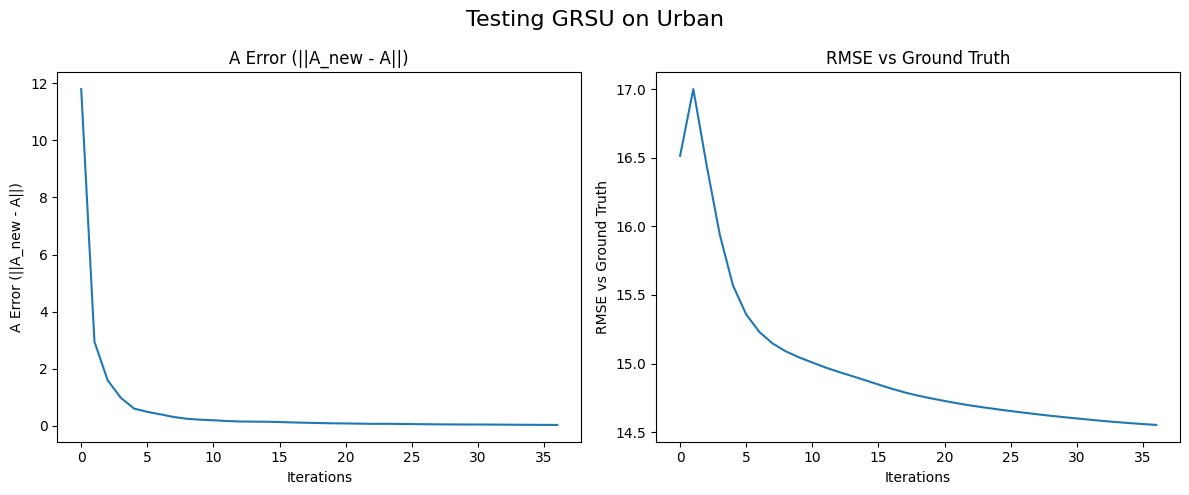

In [ ]:
samples = 2500
iters_p = 20
iters_f = 50
m_0 = 4

# Best RMSE + SAD: 18.83669850409595
# Best alpha: 20
# Best lambda: 10
# Best gamma: 100.0
# Best rho: 0.1

A_s, S_s, A_rmse_s, S_sad_rmse = best_param_grsu_glu(X = X_0, S = S_0, A = A_0, samples = samples, iters_param = iters_p, iters_final = iters_f, m_0 = m_0, print_bool = False, OH_labels = True, GRSU_bool = True, A_error = True, RMSE_plot = True, title_0 = "Testing GRSU on Urban")

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on OH...


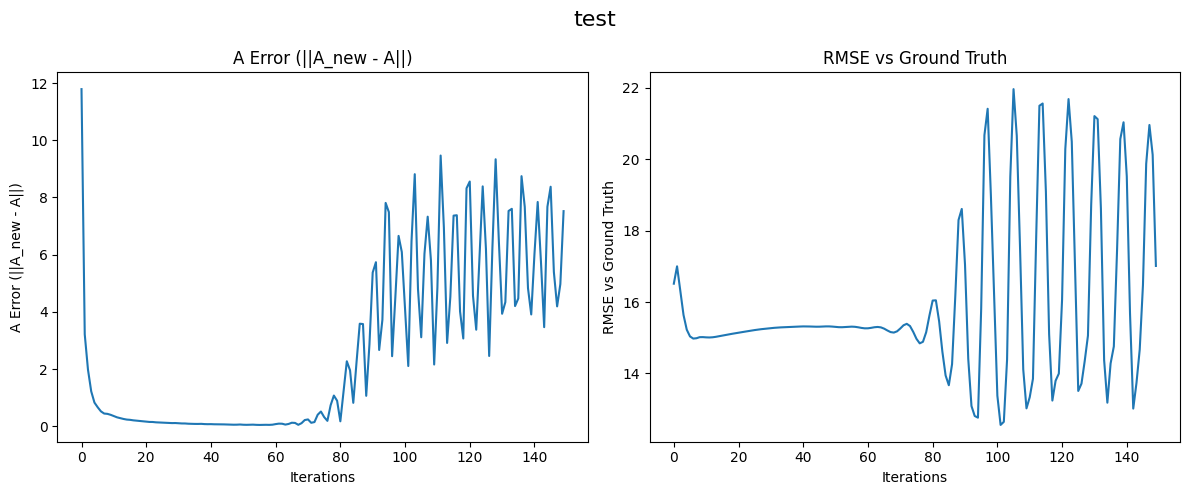

Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 13.424034115026554
Final Endmember SAD: 4.057010136575688


In [ ]:
# Cross checking with all_alg_test.ipynb
# Probably iteration issue
alpha_0 = 20
lam_0 = 100
gamma_0 = 1.0
rho_0 = 0.1
iters_f = 100

# 50 iterations
# Final Abundance Map Shape: (4, 2500)
# Final End-member Matrix Shape: (162, 4)
# Final Abundance RMSE: 15.303817584677699
# Final Endmember SAD: 4.08816486440297

# 100 iterations
# Final Abundance Map Shape: (4, 2500)
# Final End-member Matrix Shape: (162, 4)
# Final Abundance RMSE: 13.3756791034978
# Final Endmember SAD: 4.169639366238891

# 150 iterations
# Final Abundance Map Shape: (4, 2500)
# Final End-member Matrix Shape: (162, 4)
# Final Abundance RMSE: 13.424034115026554
# Final Endmember SAD: 4.057010136575688

A_s_test, S_s_test, A_rmse_s_test, S_sad_rmse_test = run_unmixing_pipeline_example(X = X_0, A_gt = A_0, S_gt = S_0, N = samples, iters = iters_f, 
                                                                                    alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = m_0, 
                                                                                    print_bool = True, OH_labels = True, GRSU_bool = True, 
                                                                                    A_error = True, RMSE_plot = True, title_0 = "test")
    

## ALMM testing

In [ ]:
# ALMM alpha testing
# TODO needs testing (works)

def best_alpha_ALMM(X, S, A, iters_param, iters_final, alpha_0 = (1e-3 + 1e-2)/2, beta_0 = (1e-3 + 1e-2)/2, gamma_0 = (1e-3 + 1e-2)/2, eta_0 = (1e-3 + 1e-2)/2, A_error = False, RMSE_plot = False, title_0 = ""):

    # Pick the best alpha
    best_rmse = np.inf
    best_alpha = None

    alpha_vals = [alpha_0, alpha_0/10, alpha_0/100, alpha_0/1000, alpha_0/10000]

    for a in alpha_vals:

        E_f, A_f, T_f, B_f = algo_2_almm_optimized(X = X, S = S, A_gt = A, 
                                                    alpha = a, beta = beta_0, gamma = gamma_0, eta = eta_0, 
                                                    maxIter = iters_param)

        # Check for labeling issues
        corr = np.corrcoef(A_f[0], A[0])[0, 1]
        if corr < 0:
            A_f_corrected = 1 - A_f
        else:
            A_f_corrected = A_f

        rmse = RMSE(A_f_corrected, A)  # Calculate RMSE
        print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_alpha = a

    print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")

    # Run on best parameters
    E_f, A_f, T_f, B_f = algo_2_almm_optimized(X = X, S = S, A_gt = A, 
                                                alpha = best_alpha, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters_final, 
                                                A_error = A_error, RMSE_plot = RMSE_plot, title_0 = title_0)

    return E_f, A_f, T_f, B_f

alpha=0.050000 -> RMSE=42.8404
alpha=0.005000 -> RMSE=36.7084
alpha=0.000500 -> RMSE=13.9443
alpha=0.000050 -> RMSE=13.4054
alpha=0.000005 -> RMSE=14.5393

Best alpha: 5e-05, RMSE: 13.4054


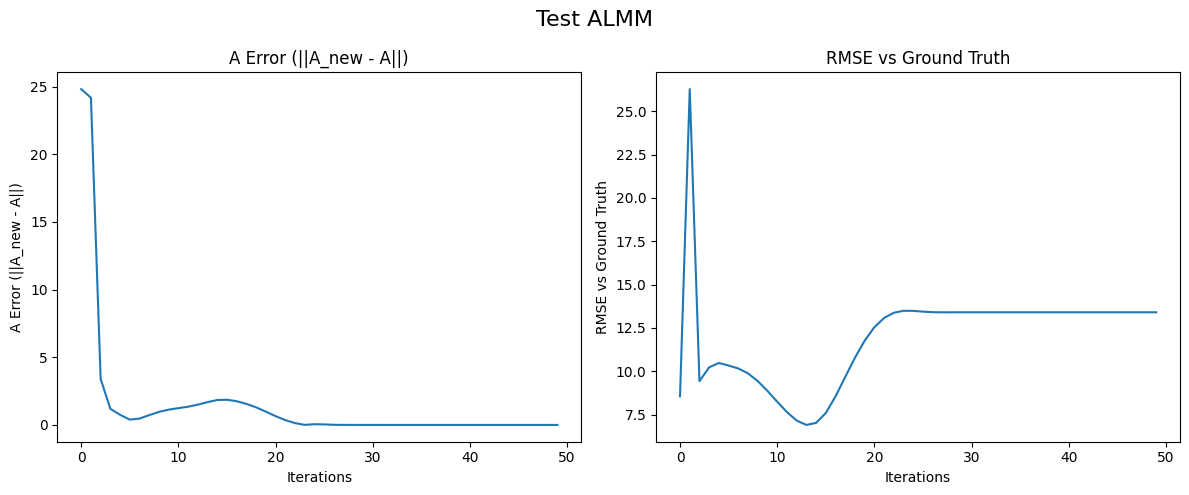

In [ ]:
# Testing (works)
alpha_almm = 5e-2
beta_almm  = 5e-2
gamma_almm  = 1e-2
eta_almm  = 1e-2
iters_p = 50
iters_f = 50

E_s, A_s, T_s, B_s = best_alpha_ALMM(X = X_0, S = S_0, A = A_0, 
                                     iters_param = iters_p, iters_final = iters_f, 
                                     alpha_0 = alpha_almm, beta_0 = beta_almm, gamma_0 = gamma_almm, eta_0 = eta_almm,
                                     A_error = True, RMSE_plot = True, title_0 = "Test ALMM")

## Plotting and Images

In [ ]:
# Abundance Map plotting
# TODO needs testing (works)

def abundance_plotting(X, A_gt, A_f_GLU, A_f_GRSU, A_f_ALMM, A_f_Graph_ALMM, title = 'Abundance Comparison (Class 2)', color_title = 'Abundance (Class 2)'):
    ## Plotting abundance maps

    # Run PCA
    pca1 = PCA(n_components=2)
    X_pca1 = pca1.fit_transform(X.T)

    # Visualizing
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    vmin, vmax = 0, 1  # fixed scale so colors are directly comparable across all 4 plots

    # Top-left: Ground truth
    sc1 = axes[0, 0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_gt[0], vmin=vmin, vmax=vmax, cmap='viridis')
    axes[0, 0].set_title('Ground Truth')

    # Top-middle: GLU
    sc2 = axes[0,1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_GLU[0], vmin=vmin, vmax=vmax, cmap='viridis')
    axes[0,1].set_title('GLU')

    # Bottom-left: GRSU
    sc3 = axes[1,0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_GRSU[0], vmin=vmin, vmax=vmax, cmap='viridis')
    axes[1,0].set_title('GRSU')

    # Bottom-middle: ALMM
    sc4 = axes[1, 1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_ALMM[0], vmin=vmin, vmax=vmax, cmap='viridis')
    axes[1, 1].set_title('ALMM')

    # # Top-right: Graph-ALMM
    sc5 = axes[0, 2].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_Graph_ALMM[0], vmin=vmin, vmax=vmax, cmap='viridis')
    axes[0, 2].set_title('Graph-ALMM')

    # Bottom-right: leave empty, or hide it
    axes[1, 2].axis('off')

    for ax in axes.flat:
        ax.set_xlabel('PC1', fontsize=12)
        ax.set_ylabel('PC2', fontsize=12)

    fig.suptitle(title, fontsize=16)

    fig.colorbar(sc4, ax=axes, label=color_title, shrink=0.8)

    plt.show()

In [49]:
# Run on whatever params
samples = 2500
alpha_c = 1e-7
beta_c = (1e-3 + 1e-2)/2
gamma_c = (1e-3 + 1e-2)/2
eta_c = (1e-3 + 1e-2)/2
iters_f = 50


# Graph ALMM
A_chem_graph_almm, S_chem_graph_almm, A_rmse_chem_graph_almm, S_sad_chem_graph_almm = run_unmixing_pipeline_example2(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                                                                                     N = samples, alpha = alpha_c, beta = beta_c, gamma = gamma_c, eta = eta_c, 
                                                                                                                     maxIter = iters_f, M_total_0 = int(0.004*samples), m_0 = 2, xi_0 = 1e-3, 
                                                                                                                     OH_labels = True, print_bool = True, 
                                                                                                                     A_error = False, RMSE_plot = False, title_0 = "")


# GLU
alpha_c_GLU = 100
lam_c_GLU = 1
gamma_c_GLU = 0.01
rho_c_GLU = 0.01

A_chem_GLU, S_chem_GLU, A_rmse_chem_GLU, S_sad_chem_GLU = run_unmixing_pipeline_example(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                                                        N = samples, iters = iters_f, alpha = alpha_c_GLU, lam = lam_c_GLU, gamma = gamma_c_GLU, rho = rho_c_GLU,
                                                                                        m_0 = 2, print_bool = True, OH_labels = True, GRSU_bool = False, 
                                                                                        A_error = False, RMSE_plot = False, title_0 = "", prep = None)


# GRSU
alpha_c_GRSU = 0.055
lam_c_GRSU = 1000
gamma_c_GRSU = 100.0
rho_c_GRSU = 100.0

A_chem_GRSU, S_chem_GRSU, A_rmse_chem_GRSU, S_sad_chem_GRSU = run_unmixing_pipeline_example(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                                                        N = samples, iters = iters_f, alpha = alpha_c_GRSU, lam = lam_c_GRSU, gamma = gamma_c_GRSU, rho = rho_c_GRSU,
                                                                                        m_0 = 2, print_bool = True, OH_labels = True, GRSU_bool = True, 
                                                                                        A_error = False, RMSE_plot = False, title_0 = "", prep = None)


# ALMM
E_chem_ALMM, A_chem_ALMM, T_chem_ALMM, B_chem_ALMM = algo_2_almm_optimized(X = X_chem, S = S_gt_chem, A_gt = A_gt_chem, 
                                                                           alpha = alpha_c, beta = beta_c, gamma = gamma_c, eta = eta_c, maxIter = iters_f, 
                                                                           A_error = False, RMSE_plot = False, title_0 = "")

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on {label_title}...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 6.9944523566545
Final Endmember SAD: 30.824258633042167
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 12.758070174832985
Final Endmember SAD: 31.42700469185277
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 5.38132859675

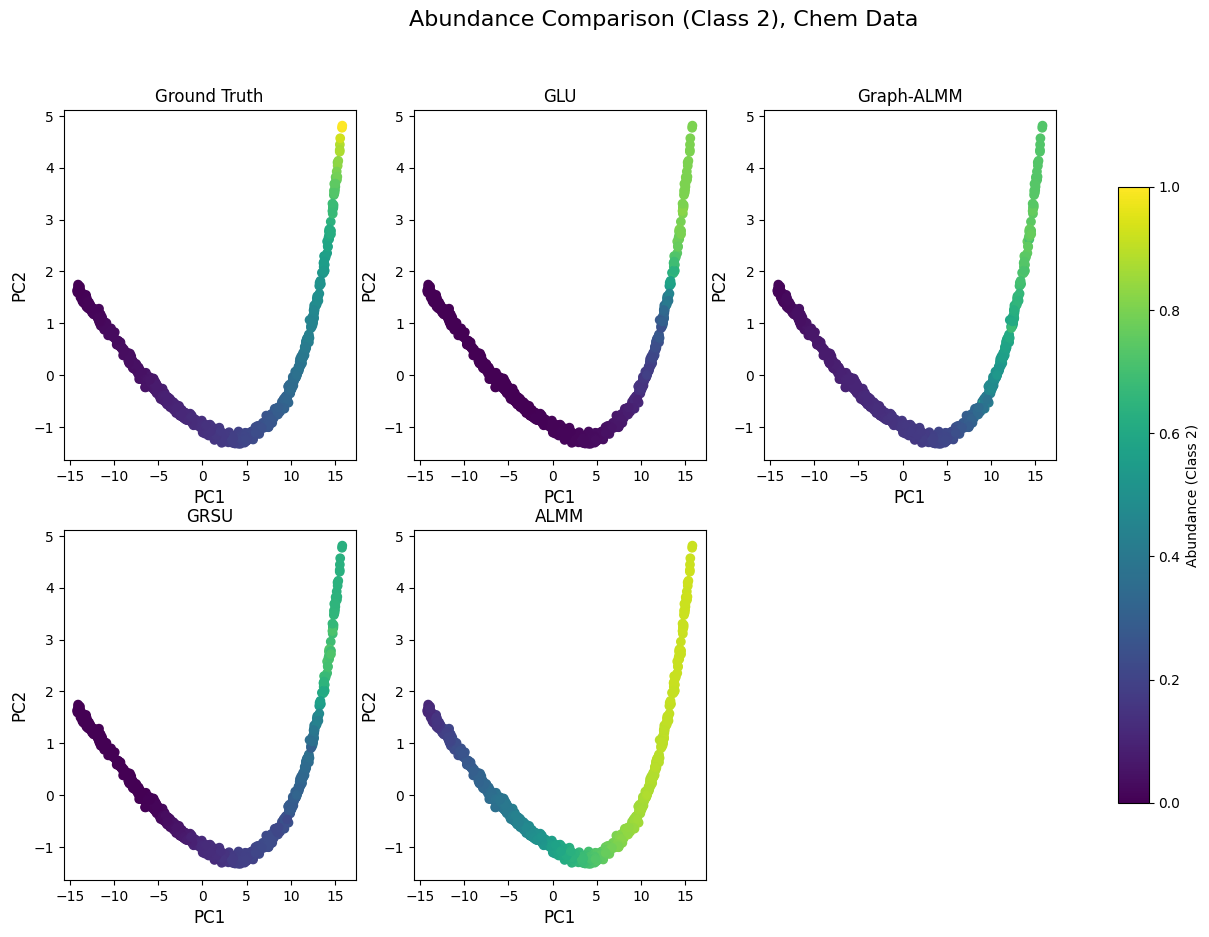

In [50]:
# Plot
abundance_plotting(X = X_chem, A_gt = A_gt_chem, A_f_GLU = A_chem_GLU, A_f_GRSU = A_chem_GRSU, A_f_ALMM = A_chem_ALMM, A_f_Graph_ALMM = A_chem_graph_almm, 
                   title = 'Abundance Comparison (Class 2), Chem Data', color_title = 'Abundance (Class 2)')

In [ ]:
# HSI image plotting
# patch_size was 50
# k = 4 for urban
# TODO needs testing (works)

def image_plotting(A_gt, A_f_GLU, A_f_GRSU, A_f_ALMM, A_f_Graph_ALMM, k, col, patch_size, class_names, algo_names):

    # Plot the images
    fig, axes =  plt.subplots(nrows=k, ncols=col, figsize=(7 ,7))
    A_gt_img = A_gt.reshape(k,patch_size,patch_size)
    A_f_GLU_img = A_f_GLU.reshape(k,patch_size,patch_size)
    A_f_GRSU_img = A_f_GRSU.reshape(k,patch_size,patch_size)
    A_f_ALMM_img = A_f_ALMM.reshape(k,patch_size,patch_size)
    A_f_Graph_ALMM_img = A_f_Graph_ALMM.reshape(k,patch_size,patch_size)

    # class_names = ['Asphalt', 'Grass', 'Tree', 'Roof']
    # algo_names = ['Ground Truth', 'GLU', 'GRSU', 'ALMM', 'ALMM-GLU']

    # Print image of each algorithm with endmembers in this order: Asphalt, Grass, Tree, Roof
    for i in range(k):
        axes[i,0].pcolormesh(A_gt_img[i], cmap='viridis')
        axes[i,1].pcolormesh(A_f_GLU_img[i], cmap='viridis')
        axes[i,2].pcolormesh(A_f_GRSU_img[i], cmap='viridis')
        axes[i,3].pcolormesh(A_f_ALMM_img[i], cmap='viridis')
        axes[i,4].pcolormesh(A_f_Graph_ALMM_img[i], cmap='viridis')

        axes[i,0].set_ylabel(class_names[i], fontsize=11) # Add endmember titles

    for j in range(col):
        axes[0, j].set_title(algo_names[j], fontsize=12)

    return

In [52]:
# Run on whatever params
samples = 2500
alpha_c = 1e-7
beta_c = (1e-3 + 1e-2)/2
gamma_c = (1e-3 + 1e-2)/2
eta_c = (1e-3 + 1e-2)/2
iters_f = 50


# Graph ALMM
A_urban_graph_almm, S_urban_graph_almm, A_rmse_urban_graph_almm, S_sad_urban_graph_almm = run_unmixing_pipeline_example2(X = X_0, A_gt = A_0, S_gt = S_0, 
                                                                                                                     N = samples, alpha = alpha_c, beta = beta_c, gamma = gamma_c, eta = eta_c, 
                                                                                                                     maxIter = iters_f, M_total_0 = int(0.004*samples), m_0 = 4, xi_0 = 1e-3, 
                                                                                                                     OH_labels = True, print_bool = True, 
                                                                                                                     A_error = False, RMSE_plot = False, title_0 = "")


# GLU
alpha_c_GLU = 100
lam_c_GLU = 1
gamma_c_GLU = 0.01
rho_c_GLU = 0.01

A_urban_GLU, S_urban_GLU, A_rmse_urban_GLU, S_sad_urban_GLU = run_unmixing_pipeline_example(X = X_0, A_gt = A_0, S_gt = S_0, 
                                                                                        N = samples, iters = iters_f, alpha = alpha_c_GLU, lam = lam_c_GLU, gamma = gamma_c_GLU, rho = rho_c_GLU,
                                                                                        m_0 = 4, print_bool = True, OH_labels = True, GRSU_bool = False, 
                                                                                        A_error = False, RMSE_plot = False, title_0 = "", prep = None)


# GRSU
alpha_c_GRSU = 0.055
lam_c_GRSU = 1000
gamma_c_GRSU = 100.0
rho_c_GRSU = 100.0

A_urban_GRSU, S_urban_GRSU, A_rmse_urban_GRSU, S_sad_urban_GRSU = run_unmixing_pipeline_example(X = X_0, A_gt = A_0, S_gt = S_0, 
                                                                                        N = samples, iters = iters_f, alpha = alpha_c_GRSU, lam = lam_c_GRSU, gamma = gamma_c_GRSU, rho = rho_c_GRSU,
                                                                                        m_0 = 4, print_bool = True, OH_labels = True, GRSU_bool = True, 
                                                                                        A_error = False, RMSE_plot = False, title_0 = "", prep = None)


# ALMM
E_urban_ALMM, A_urban_ALMM, T_urban_ALMM, B_urban_ALMM = algo_2_almm_optimized(X = X_0, S = S_0, A_gt = A_0, 
                                                                           alpha = alpha_c, beta = beta_c, gamma = gamma_c, eta = eta_c, maxIter = iters_f, 
                                                                           A_error = False, RMSE_plot = False, title_0 = "")

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on {label_title}...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 16.84624585300619
Final Endmember SAD: 16.852159929482777
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 16.515091863060118
Final Endmember SAD: 4.21879358650324
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 16.332066320534

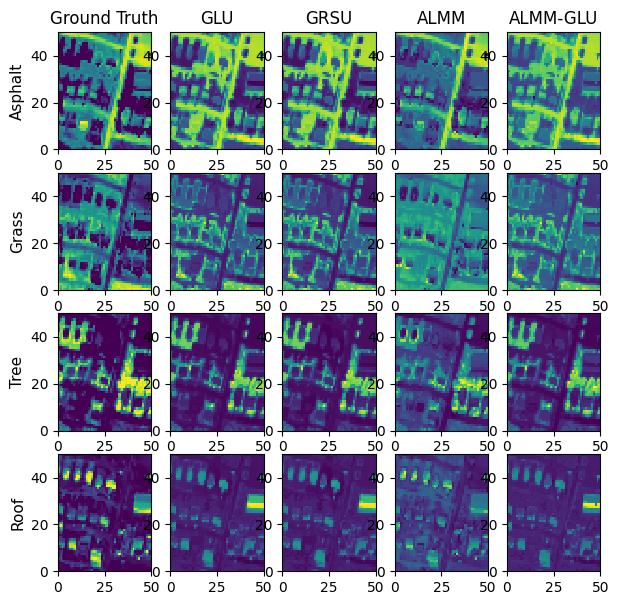

In [54]:
class_names = ['Asphalt', 'Grass', 'Tree', 'Roof']
algo_names = ['Ground Truth', 'GLU', 'GRSU', 'ALMM', 'ALMM-GLU']

image_plotting(A_gt = A_0, A_f_GLU = A_urban_GLU, A_f_GRSU = A_urban_GRSU, A_f_ALMM = A_urban_ALMM, A_f_Graph_ALMM = A_urban_graph_almm, 
               k = 4, col = 5, patch_size = 50, class_names = class_names, algo_names = algo_names)

## Energy Functions

### GRSU

In [40]:
# TODO Double check this code generated by Claude

def compute_I1_I2(A, A_hat, W, M):
    W_uu = W[M:, M:] # unlabeled to unlabeled
    W_ul = W[M:, :M] # unlabeled to labeled
    
    A_sq = np.sum(A**2, axis=0)
    dist_sq_uu = A_sq[:, None] + A_sq[None, :] - 2*(A.T @ A)
    I1 = 0.25 * W_uu.multiply(dist_sq_uu).sum()
    
    Ahat_sq = np.sum(A_hat**2, axis=0)
    dist_sq_ul = A_sq[:, None] + Ahat_sq[None, :] - 2*(A.T @ A_hat)
    I2 = 0.25 * W_ul.multiply(dist_sq_ul).sum()
    
    return I1, I2

In [18]:
# Needs proofreading

def GRSU_energy(X, S, A, W, M, X_hat, A_hat, alpha, lambda_0):
    
    # Least Squares Problem
    term1 = 0.5 * (np.linalg.norm(X - (S @ A), 'fro') ** 2)

    # Label information
    term2 = ((alpha ** 2) / 2) * (np.linalg.norm(X_hat - (S @ A_hat), 'fro') ** 2)

    # Graph regularization (I1 + I2, equivalent to the inner product)
    I1, I2 = compute_I1_I2(A = A, A_hat = A_hat, W = W, M = M)

    return term1 + term2 + (lambda_0 * I1) + (lambda_0 * I2)

### ALMM

In [48]:
# Needs proofreading

def ALMM_energy(X, S, A, T, E, B, alpha, beta, gamma, eta):

    L = E.shape[1]
    I_L = np.eye(L)

    # Least Squares Problem
    term1 = 0.5 * (np.linalg.norm(X - ((S @ A) * T) - (E @ B), 'fro') ** 2)

    # Sparsity Regularization (L1)
    term2 = alpha * np.linalg.norm(A, ord = 1)

    # Generalization for Spectral Variability
    term3 = (beta / 2) * (np.linalg.norm(B, 'fro') ** 2)

    # Low-coherence with endmember dictionary and orthogonality
    term4 = (gamma / 2) * (np.linalg.norm(S.T @ E) ** 2) + (eta / 2) * (np.linalg.norm(E.T @ E - I_L, 'fro') ** 2)

    return term1 + term2 + term3 + term4

### Graph ALMM

In [76]:
# TODO figure out the lambda term
# Treat xi = rho / lambda, for rho = 1, or omit the factor entirely

def Graph_ALMM_energy(X, S, A, A_hat, T, E, B, W, M, alpha, beta, gamma, eta, xi):

    L = E.shape[1]
    I_L = np.eye(L)

    # Least Squares Problem
    term1 = 0.5 * (np.linalg.norm(X - ((S @ A) * T) - (E @ B), 'fro') ** 2)

    # Sparsity Regularization (L1/2)
    term2 = alpha * np.sum(np.sqrt(np.abs(A)))

    # Generalization for Spectral Variability
    term3 = (beta / 2) * (np.linalg.norm(B, 'fro') ** 2)

    # Low-coherence with endmember dictionary and orthogonality
    term4 = (gamma / 2) * (np.linalg.norm(S.T @ E) ** 2) + (eta / 2) * (np.linalg.norm(E.T @ E - I_L, 'fro') ** 2)

    # Graph Regularization Term
    A_unlabeled = A[:, M:]
    I1, I2 = compute_I1_I2(A = A_unlabeled, A_hat = A_hat, W = W, M = M)

    return term1 + term2 + term3 + term4 + ((1/xi)*I1) + ((1/xi)*I2)

### Modified functions (remove later)

In [30]:
def graph_plotter_test(i, A_error, RMSE_plot, Energy_plot, A_error_array, RMSE_array, Energy_array, title_0):
    x_iterations = [j for j in range(i)]

    plots_to_show = []
    if A_error:
        plots_to_show.append(("A Error (||A_new - A||)", A_error_array))
    if RMSE_plot:
        plots_to_show.append(("RMSE", RMSE_array))
    if Energy_plot:
        plots_to_show.append(("Energy", Energy_array))

    if plots_to_show:
        fig, axes = plt.subplots(1, len(plots_to_show), figsize=(6*len(plots_to_show), 5))
        if len(plots_to_show) == 1:
            axes = [axes]  # make it indexable even with just one subplot

        for ax, (title, data) in zip(axes, plots_to_show):
            ax.plot(x_iterations, data)
            ax.set_xlabel("Iterations")
            ax.set_ylabel(title)
            ax.set_title(title)

        fig.suptitle(title_0, fontsize=16)
        plt.tight_layout()
        plt.show()

    return

In [78]:
def algo_3_grsu_test(X, X_hat, A_hat, alpha, lam, gamma, rho, A_gt, S_gt, max_iters=1000, eps=1e-30, k=50, A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = ""):
    """
    Executes the Graph-Regularized Semi-Supervised Unmixing (GRSU) model (Algorithm 3).

    Parameters:
    X (numpy.ndarray): Unlabeled data matrix (p, N).
    X_hat (numpy.ndarray): Labeled data matrix (p, M).
    A_hat (numpy.ndarray): Labeled abundance matrix / pseudo-labels (q, M).
    alpha (float): Weighting parameter for end-member estimation.
    lam (float): Graph regularization parameter (lambda).
    gamma (float): ADMM penalty parameter for S-T constraint.
    rho (float): ADMM penalty parameter for A-B constraint.
    max_iters (int): Maximum number of ADMM iterations.
    eps (float): Error tolerance for convergence.
    k (int): Number of nearest neighbors for graph construction.

    Returns:
    A_GRSU (numpy.ndarray): Final estimated abundance map (q, N).
    S_GRSU (numpy.ndarray): Final estimated end-member spectrum matrix (p, q).
    """
    p, N = X.shape
    q, M = A_hat.shape
    A_error_array = []
    RMSE_array = []
    Energy_array = []

    # --- 1. Graph Construction & Laplacian Partitioning ---
    X_tilde = np.concatenate((X_hat, X), axis=1)
    G, W = build_custom_knn_graph(X_tilde.T, K=k)

    labeled_indices = np.arange(M)
    L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, labeled_indices)

    # --- 2. Initialization via GLU (Algorithm 2) ---
    A, S = algo_2_glu(X, X_hat, A_hat, alpha, k=k)

    # Initialize ADMM auxiliary and dual variables
    B = np.copy(A)
    B_bar = np.zeros((q, N))
    T_bar = np.zeros((p, q))

    # Pre-compute constants that do not change during iterations
    I_q = np.eye(q)
    I_N_sparse = sps.eye(N, format='csr')

    # Terms in T's update
    X_hat_A_hat_T_alpha2 = (alpha**2) * (X_hat @ A_hat.T)
    A_hat_A_hat_T_alpha2 = (alpha**2) * (A_hat @ A_hat.T)

    # Terms in B's update
    L_B_system = L_uu + (rho / lam) * I_N_sparse
    L_lu_T_A_hat_T = L_lu.T @ A_hat.T # Shape: (N, q)

    Err = 1.0
    i = 0

    # --- 3. ADMM Iteration Loop ---
    while i < max_iters and Err > eps:

        # a) T subproblem update
        term1_T = (X @ A.T) + X_hat_A_hat_T_alpha2 + gamma * (S + T_bar)
        term2_T = (A @ A.T) + A_hat_A_hat_T_alpha2 + gamma * I_q
        T = term1_T @ np.linalg.inv(term2_T)

        # b) S subproblem update
        S_new = np.maximum(T - T_bar, 0)

        # c) A subproblem update
        term1_A = np.linalg.inv((S_new.T @ S_new) + rho * I_q)
        term2_A = (S_new.T @ X) + rho * (B - B_bar)
        A_unproj = term1_A @ term2_A
        A_new = project_onto_simplex(A_unproj)

        # d) B subproblem update (Graph Regularized Laplace Learning)
        # We solve the transposed system: L_B_system * B^T = RHS_B
        RHS_B = -L_lu_T_A_hat_T + (rho / lam) * (A_new.T + B_bar.T)
        B_new_T = np.zeros((N, q))

        for j in range(q):
            B_new_T[:, j], _ = spla.cg(L_B_system, RHS_B[:, j])
        B_new = B_new_T.T

        # e) Update dual variables
        B_bar_new = B_bar + (A_new - B_new)
        T_bar_new = T_bar + (S_new - T)

        # f) Calculate convergence error
        # Protect against division by zero in the denominator
        norm_S = np.linalg.norm(S, 'fro')
        norm_A = np.linalg.norm(A, 'fro')

        err_S = np.linalg.norm(S_new - S, 'fro') / norm_S if norm_S > 0 else 0
        err_A = np.linalg.norm(A_new - A, 'fro') / norm_A if norm_A > 0 else 0

        Err = max(err_S, err_A)

        # g) Advance state for next iteration

        # Calculate error
        if A_error:
            A_error_array.append(np.linalg.norm(A_new - A))
        if RMSE_plot:
            RMSE_array.append(RMSE(A, A_gt))
        if Energy_plot:
            Energy_array.append(GRSU_energy(X = X, S = S, A = A, W = W, M = M, 
                                            X_hat = X_hat, A_hat = A_hat, alpha = alpha, lambda_0 = lam))

        S = S_new
        A = A_new
        B = B_new
        B_bar = B_bar_new
        T_bar = T_bar_new

        i += 1
    
    # Plot
    graph_plotter_test(i = i, A_error = A_error, RMSE_plot = RMSE_plot, Energy_plot = Energy_plot,
                  A_error_array = A_error_array, RMSE_array = RMSE_array, Energy_array = Energy_array, title_0 = title_0) 

    return A, S

In [79]:
def run_unmixing_pipeline_example_test(X, A_gt, S_gt, N, iters, alpha = 10.0, lam = 1.0, gamma = 1.0, rho = 1.0, m_0 = 2, print_bool = True, OH_labels = True, GRSU_bool = True, A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "", prep = None):
    # ==========================================
    # Phase 0: Load Data (Mocking Jasper Ridge)
    # ==========================================
    #print("Loading data...")
    #N = 10000  # Number of pixels (e.g., 100x100 image)
    #p = 198    # Number of spectral bands [cite: 286]
    #q = 4      # Number of latent end-members (Tree, Water, Dirt, Road) [cite: 287, 288]

    # Mock full hyperspectral image X: shape (p, N)
    #X = np.random.rand(p, N, seed=42)

    # Mock ground-truth abundance map (only used to simulate human labeling)
    #A_gt = np.random.dirichlet(np.ones(q), size=N, seed=42).T

    # Run Phase 1 and Phase 2 if it isn't already given

    if prep is None:
        # ==========================================
        # Phase 1: Active Learning (Algorithm 1)
        # ==========================================
        if print_bool:
            print("Building initial graph for Active Learning...")
        # Scikit-learn expects (samples, features), so we pass X.T
        # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
        G, W = build_custom_knn_graph(X.T, K=int(N*0.005))

        if print_bool:
            print("Running Active Learning...")
        # Start with 1 random pixel per material (m=4), sample up to 0.4% of total pixels (M=40) [cite: 323]
        # num_eigs = 0.5% of the pixels (equal to K)?
        labeled_indices = algo_1_active_learning(X, W, m_initial=m_0, M_total=int(0.004*N), num_eigs=int(N*0.005))

        # ==========================================
        # Phase 2: Extract Training Data
        # ==========================================
        if print_bool:
            print("Extracting training data and generating pseudo-labels...")
        # Extract the spectral signatures for the selected pixels
        X_hat = X[:, labeled_indices]

        # Extract ground-truth abundances and convert to One-Hot pseudo-labels [cite: 321, 322]
        A_hat_exact = A_gt[:, labeled_indices]
        A_hat_OH = generate_one_hot_labels(A_hat_exact)

        # Pick between Exact or OH labels
        if OH_labels:
            A_hat_test = A_hat_OH
            label_title = "OH"
        else:
            A_hat_test = A_hat_exact
            label_title = "Exact"

    else:
        # Extract values from array
        X_hat = prep[0]
        A_hat_test = prep[1]
        label_title = prep[2]

    # ==========================================
    # Phase 3: Semi-Supervised Unmixing
    # ==========================================
    if print_bool and GRSU_bool:
        print(f"Running GRSU (and GLU) Unmixing on {label_title}...")
    elif print_bool:
         print(f"Running GLU Unmixing on {label_title}...")

    # Hyperparameters based on the Jasper Ridge dataset in Table II [cite: 339, 340]
    # alpha = 10.0
    # lam = 1.0
    # gamma = 1.0
    # rho = 1.0

    # Note: The paper mentions an overlap between X_hat and X, but updates
    # the abundance map for all pixels in X anyway.

    # If we are only running GLU
    if not GRSU_bool:
        A_final, S_final = algo_2_glu(X, X_hat, A_hat_test, alpha, k=int(N*0.005))
    else:
        A_final, S_final = algo_3_grsu_test(
            X=X,
            X_hat=X_hat,
            A_hat=A_hat_test,
            alpha=alpha,
            lam=lam,
            gamma=gamma,
            rho=rho,
            max_iters=iters,
            A_gt = A_gt,
            S_gt = S_gt,
            eps=1e-30,
            k=int(N*0.005),
            A_error = A_error,
            RMSE_plot = RMSE_plot,
            Energy_plot = Energy_plot,
            title_0 = title_0
        )

    # Calculate RMSE and SAD
    A_rmse = RMSE(A_final, A_gt)
    S_sad = SAD(S_final, S_gt)

    if print_bool:
        print("Pipeline Complete!\n")
        print(f"Final Abundance Map Shape: {A_final.shape}")
        print(f"Final End-member Matrix Shape: {S_final.shape}")
        print(f"Final Abundance RMSE: {A_rmse}")
        print(f"Final Endmember SAD: {S_sad}")

    return A_final, S_final, A_rmse, S_sad

In [26]:
X_0, S_0, A_0 = load_data(name = 'processed_data/processed_data/urban/urban_processed_data.npy', typename = 'HSI', sample = True)

Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <class 'numpy.ndarray'>
Shape of X: (162, 94249)

Type of A: <class 'dict'>
Keys inside A: dict_keys(['A_ref', 'A_fclsu', 'A_MBO', 'A_graphL', 'A_MSC', 'A_qmv', 'A_nmf', 'A_EGU'])

Type of S: <class 'dict'>
Keys inside S: dict_keys(['S_ref', 'S_fclsu', 'S_MBO', 'S_graphL', 'S_MSC', 'S_qmv', 'S_nmf', 'S_EGU'])
X (reshaped): (162, 2500)


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on OH...


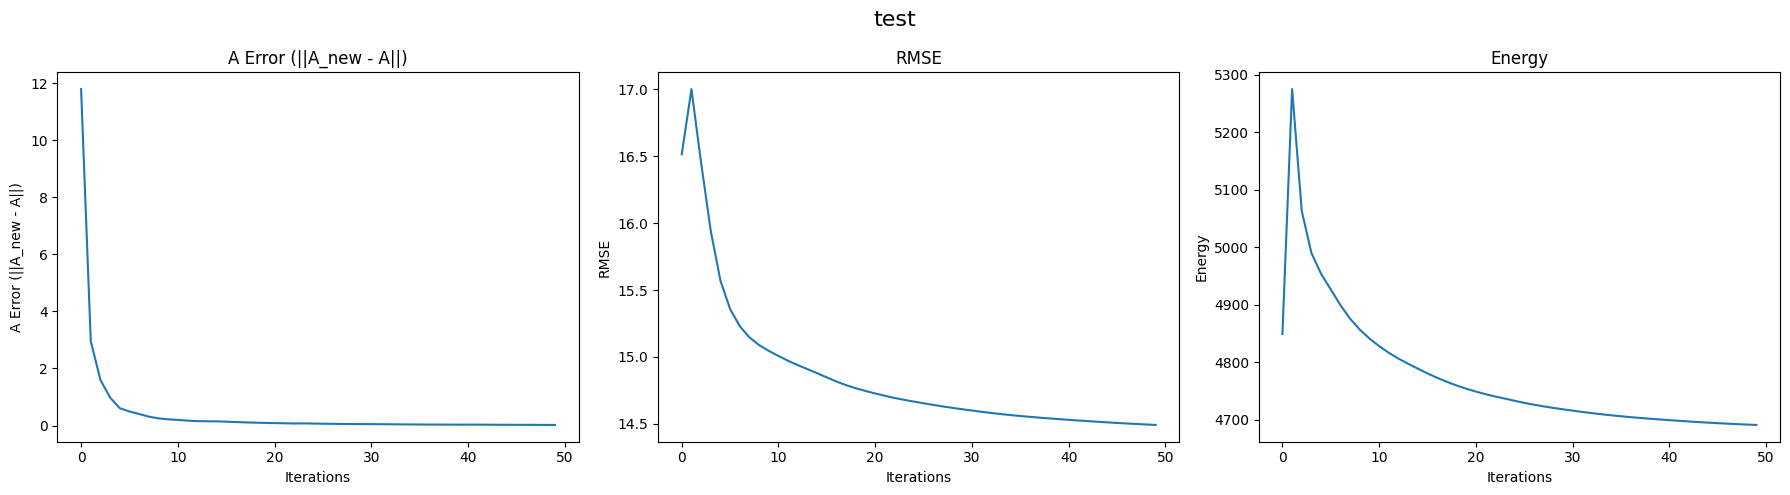

Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 14.488159643470158
Final Endmember SAD: 4.095789054564627


In [80]:
# GRSU
# Best RMSE + SAD: 18.83669850409595
# Best alpha: 20
# Best lambda: 10
# Best gamma: 100.0
# Best rho: 0.1

samples = 2500
iters_f = 50
alpha_0 = 20
lam_0 = 10
gamma_0 = 100.0
rho_0 = 0.1
m_0 = 4


A_s_test, S_s_test, A_rmse_s_test, S_sad_rmse_test = run_unmixing_pipeline_example_test(X = X_0, A_gt = A_0, S_gt = S_0, N = samples, iters = iters_f, 
                                                                                    alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = m_0, 
                                                                                    print_bool = True, OH_labels = True, GRSU_bool = True, 
                                                                                    A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "test")

In [49]:
def algo_2_almm_optimized_test(X, S, A_gt, alpha, beta, gamma, eta, maxIter, A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = ""):
    """
    Optimized ALMM-Based SVDL.
    Note: Requires passing A_initial (from SCLSU) as an argument since 
    SCLSU is not defined in the scope of this snippet.
    """
    A_initial = SCLSU(X, S)
    p, N = X.shape
    p, q = S.shape
    L = int(p / 2)
    A_error_array = []
    RMSE_array = []
    Energy_array = []

    # 1. Precompute loop-invariant matrices
    StS = S.T @ S
    StX = S.T @ X
    gamma_SSt = gamma * (S @ S.T)

    # Initialize standard variables
    G = np.zeros((q, N))
    H = np.zeros((q, N))
    M = np.zeros((q, N))
    B = np.zeros((L, N))

    # 2. Track N x N diagonal matrices as 1D vectors to save O(N^2) memory
    t_diag = np.ones(N)       # Equivalent to np.eye(N)
    delta_diag = np.zeros(N)  # Equivalent to np.zeros((N, N))
    u_diag = np.zeros(N)      # Equivalent to np.zeros((N, N))

    Lambda = np.zeros((q, N)) 
    Upsilon = np.zeros((q, N)) 
    Omega = np.zeros((q, N)) 

    Q = np.zeros((p, L)) 
    Pi = np.zeros((p, L)) 

    A = np.copy(A_initial)

    # Generate random orthogonal matrix for E
    np.random.seed(42)
    random_matrix = np.random.randn(p, L)
    E, _ = np.linalg.qr(random_matrix)

    # Initialize scalars
    t = 0
    xi = 1e-3
    xi_max = 1e6
    rho = 1.5
    epsilon = 1e-6
    converged = False

    # Identity matrices for subproblems (sizes q, L, p only!)
    I_q = np.eye(q)
    I_L = np.eye(L)
    I_p = np.eye(p)

    while (not converged) and t < maxIter:
        
        # M subproblem (solve instead of inv)
        # S.T @ E @ B evaluated as (S.T @ E) @ B for faster multiplication
        term2_M = StX - (S.T @ E) @ B + (xi * (A * t_diag)) - Omega
        M_new = np.linalg.solve(StS + xi * I_q, term2_M)

        # B subproblem
        term2_B = (E.T @ X) - (E.T @ S) @ M_new
        B_new = np.linalg.solve((E.T @ E) + beta * I_L, term2_B)

        # A subproblem
        # Multiplication by diagonal matrix T is just broadcasting: * t_diag
        term1_A = (xi * G) + Lambda + (xi * H) + Upsilon + (Omega * t_diag) + (xi * M_new * t_diag)
        
        # term2_A was purely diagonal, so we just divide by the diagonal values!
        diag_inv = 1.0 / (xi * (t_diag ** 2) + 2 * xi)
        A_new = term1_A * diag_inv
        A_new = A_new / (A_new.sum(axis=0, keepdims=True) + 1e-10)

        # T subproblem (Woodbury Matrix Identity to avoid N x N operations)
        Y = xi * M_new + Omega
        A_At = A_new @ A_new.T
        
        # K = (I_q + A A^T)^{-1}. Since q is small (e.g. 10), this is instant.
        K = np.linalg.solve(I_q + A_At, I_q) 
        
        # Calculate exactly the diagonal components needed
        Z = Y - (K @ A_At) @ Y
        diag_At_Z = np.sum(A_new * Z, axis=0) # Fast way to get diag of A^T Z
        diag_A_K_A = np.sum(A_new * (K @ A_new), axis=0)
        
        D = xi * u_diag + delta_diag
        T_new_diag = (1.0 / xi) * diag_At_Z + (1.0 / xi) * D * (1.0 - diag_A_K_A)

        # E subproblem (Right-side solve using Transpose)
        term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q) + Pi
        term2_E_inv = (B_new @ B_new.T) + xi * I_L
        E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # Q subproblem
        term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        term2_Q = (eta * Q) + (xi * E_new) - Pi
        Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # G, H, U subproblems
        term1_G = np.maximum(0, np.abs(A_new - (Lambda / xi)) - (alpha / xi))
        term2_G = np.sign(A_new - (Lambda / xi))
        G_new = term1_G * term2_G 
        H_new = np.maximum(0, A_new - (Upsilon / xi))
        U_new_diag = np.maximum(0, T_new_diag - (delta_diag / xi))

        # AT subproblem 
        AT_new = A_new * T_new_diag

        # Update Lagrange multipliers
        Lambda_new = Lambda + xi * (G_new - A_new)
        Upsilon_new = Upsilon + xi * (H_new - A_new)
        Omega_new = Omega + xi * (M_new - AT_new)
        Pi_new = Pi + xi * (Q_new - E_new)
        delta_diag_new = delta_diag + xi * (U_new_diag - T_new_diag)

        xi_new = min(rho * xi, xi_max)

        # Check convergence conditions
        if ((np.linalg.norm(G_new - A_new) < epsilon) and 
            (np.linalg.norm(H_new - A_new) < epsilon) and
            (np.linalg.norm(M_new - AT_new) < epsilon) and
            (np.linalg.norm(Q_new - E_new) < epsilon) and 
            (np.linalg.norm(U_new_diag - T_new_diag) < epsilon) and
            (np.linalg.norm(E_new - E) < epsilon)):

            converged = True
        else:
            t += 1

            # Calculate error
            if A_error:
                A_error_array.append(np.linalg.norm(A_new - A))
            if RMSE_plot:
                # Check for labeling issues
                corr = np.corrcoef(A[0], A_gt[0])[0, 1]
                if corr < 0:
                    A_f_corrected = 1 - A
                else:
                    A_f_corrected = A

                rmse = RMSE(A_f_corrected, A_gt)  # Calculate RMSE
                RMSE_array.append(rmse)
            if Energy_plot:
                Energy_array.append(ALMM_energy(X = X, S = S, A = A, T = t_diag, 
                                                E = E, B = B, alpha = alpha, beta = beta, gamma = gamma, eta = eta))

            M = M_new
            B = B_new
            A = A_new
            t_diag = T_new_diag
            E = E_new
            Q = Q_new
            G = G_new
            H = H_new
            u_diag = U_new_diag

            Lambda = Lambda_new
            Upsilon = Upsilon_new
            Omega = Omega_new
            Pi = Pi_new
            delta_diag = delta_diag_new
            xi = xi_new

    # Reconstruct the N x N diagonal matrix T at the very end to match expected output signature
    T_final = np.diag(t_diag)

    # Plot
    graph_plotter_test(i = t, A_error = A_error, RMSE_plot = RMSE_plot, Energy_plot = Energy_plot,
                  A_error_array = A_error_array, RMSE_array = RMSE_array, Energy_array = Energy_array, title_0 = title_0) 
    
    return E, A, T_final, B

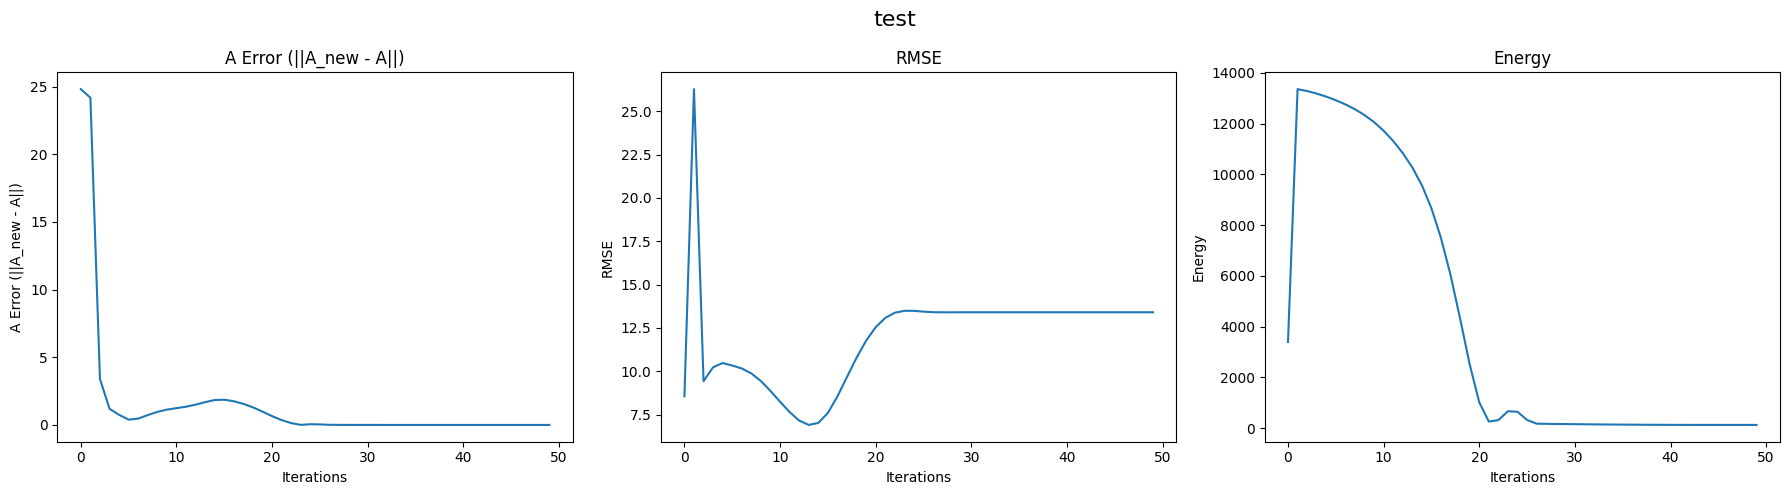

In [51]:
# ALMM
alpha_almm = 5e-5
beta_almm  = 5e-2
gamma_almm  = 1e-2
eta_almm  = 1e-2

E_f_almm_test, A_f_almm_test, T_f_almm_test, B_f_almm_test = algo_2_almm_optimized_test(X = X_0, S = S_0, A_gt = A_0, 
                                                                                        alpha = alpha_almm, beta = beta_almm, gamma = gamma_almm, eta = eta_almm, maxIter = 50, 
                                                                                        A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "test")

In [72]:
def algo_2_graph_almm_optimized_test(X, A_0, S, alpha, beta, gamma, eta, maxIter, xi_0, L_uu, L_lu_T_A_hat_T, A_gt, A_hat, W, labeled_indices, A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = ""):
    """
    Optimized ALMM-Based SVDL.
    Note: Requires passing A_initial (from SCLSU) as an argument since 
    SCLSU is not defined in the scope of this snippet.
    """
    p, N = X.shape
    p, q = S.shape
    q, M_0 = A_hat.shape

    L = int(p / 2)
    A_error_array = []
    RMSE_array = []
    Energy_array = []
    #A_0 = SCLSU(X, S)
    #print("Number of labeled points:", len(labeled_indices))

    # 1. Precompute loop-invariant matrices
    StS = S.T @ S
    StX = S.T @ X
    gamma_SSt = gamma * (S @ S.T)

    # Initialize standard variables
    G = np.zeros((q, N))
    H = np.zeros((q, N))
    M = np.zeros((q, N))
    B = np.zeros((L, N))

    # 2. Track N x N diagonal matrices as 1D vectors to save O(N^2) memory
    t_diag = np.ones(N)       # Equivalent to np.eye(N)
    delta_diag = np.zeros(N)  # Equivalent to np.zeros((N, N))
    u_diag = np.zeros(N)      # Equivalent to np.zeros((N, N))

    Lambda = np.zeros((q, N)) 
    Upsilon = np.zeros((q, N)) 
    Omega = np.zeros((q, N)) 

    Q = np.zeros((p, L)) 
    Pi = np.zeros((p, L)) 

    A = np.copy(A_0)

    # Generate random orthogonal matrix for E
    np.random.seed(42)
    # random_matrix = np.random.randn(p, L)
    # E, _ = np.linalg.qr(random_matrix)

    # E = S - vca(X)
    Ae, _, _ = vca(X, R = q)
    diff = S - Ae


    # Pad with random columns to reach L total, then orthogonalize via QR
    pad = np.random.randn(p, L - diff.shape[1])
    E_init_raw = np.hstack([diff, pad])   # shape (p, L)

    E, _ = np.linalg.qr(E_init_raw)       # (p, L), orthonormal columns, but "seeded" by your real diff


    # Initialize scalars
    t = 0
    xi = xi_0 # originally 1e-3
    xi_max = 1e6
    rho = 1.5
    epsilon = 1e-6
    converged = False

    # Identity matrices for subproblems (sizes q, L, p only!)
    I_q = np.eye(q)
    I_L = np.eye(L)
    I_p = np.eye(p)

    # Derive unlabeled indices from labeled_indices (test)
    all_indices = np.arange(N)
    unlabeled_indices = np.setdiff1d(all_indices, labeled_indices)
    N_unlabeled = len(unlabeled_indices)  # should match L_uu.shape[0]

    while (not converged) and t < maxIter:
        
        # M subproblem (solve instead of inv)
        # S.T @ E @ B evaluated as (S.T @ E) @ B for faster multiplication
        term2_M = StX - (S.T @ E) @ B + (xi * (A * t_diag)) - Omega
        M_new = np.linalg.solve(StS + xi * I_q, term2_M)

        # B subproblem
        term2_B = (E.T @ X) - (E.T @ S) @ M_new
        B_new = np.linalg.solve((E.T @ E) + beta * I_L, term2_B)

        # A subproblem
        # Multiplication by diagonal matrix T is just broadcasting: * t_diag
        term1_A = ((xi* 1) * G) + Lambda + ((xi *2)* H) + Upsilon + (Omega * t_diag) + (xi * M_new * t_diag)
        
        # term2_A was purely diagonal, so we just divide by the diagonal values!
        diag_inv = 1.0 / (xi * (t_diag ** 2) + 2 * xi)
        A_new_unproj = term1_A * diag_inv
        A_new_unproj = A_new_unproj / (A_new_unproj.sum(axis=0, keepdims=True) + 1e-10)
        A_new = project_onto_simplex(A_new_unproj) # Project onto the simplex for nonnegativity

        # T subproblem (Woodbury Matrix Identity to avoid N x N operations)
        Y = xi * M_new + Omega
        A_At = A_new @ A_new.T
        
        # K = (I_q + A A^T)^{-1}. Since q is small (e.g. 10), this is instant.
        K = np.linalg.solve(I_q + A_At, I_q) 
        
        # Calculate exactly the diagonal components needed
        Z = Y - (K @ A_At) @ Y
        diag_At_Z = np.sum(A_new * Z, axis=0) # Fast way to get diag of A^T Z
        diag_A_K_A = np.sum(A_new * (K @ A_new), axis=0)
        
        D = xi * u_diag + delta_diag
        T_new_diag = (1.0 / xi) * diag_At_Z + (1.0 / xi) * D * (1.0 - diag_A_K_A)

        # # E subproblem (Right-side solve using Transpose)
        # term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q) + Pi
        # term2_E_inv = (B_new @ B_new.T) + xi * I_L
        # E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # # Q subproblem
        # term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        # term2_Q = (eta * Q) + (xi * E_new) - Pi
        # Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # Q subproblem
        term1_Q_inv = gamma_SSt + (eta * Q @ Q.T) + xi * I_p
        term2_Q = (eta * Q) + (xi * E) - Pi
        Q_new = np.linalg.solve(term1_Q_inv, term2_Q)

        # E subproblem (Right-side solve using Transpose)
        term1_E = (X @ B_new.T) - S @ (M_new @ B_new.T) + (xi * Q_new) + Pi
        term2_E_inv = (B_new @ B_new.T) + xi * I_L
        E_new = np.linalg.solve(term2_E_inv, term1_E.T).T

        # G, H, U subproblems
        # term1_G = np.maximum(0, np.abs(A_new - (Lambda / xi)) - (alpha / xi))
        # term2_G = np.sign(A_new - (Lambda / xi))
        # G_new = term1_G * term2_G 

        Z_0 = A_new - (Lambda / xi)
        G_new = half_threshold(Z_0, alpha, xi)

        # Replacing G update with B

        # # Terms in B's update (replaced rho / lam with xi for now)
        # I_N_sparse = sps.eye(N, format='csr')
        # L_B_system = L_uu + (xi) * I_N_sparse
        # #L_lu_T_A_hat_T = L_lu.T @ A_hat.T # Shape: (N, q)

        # RHS_G = -L_lu_T_A_hat_T + (xi) * A_new.T + Lambda.T
        # G_new_T = np.zeros((N, q))

        # for j in range(q):
        #     G_new_T[:, j], _ = spla.cg(L_B_system, RHS_G[:, j])
        # G_new = G_new_T.T


        # H subproblem — solve only on unlabeled portion
        I_N_unlabeled_sparse = sps.eye(N_unlabeled, format='csr')
        L_B_system = L_uu + xi * I_N_unlabeled_sparse

        # Only take unlabeled columns of A_new and Lambda for the RHS
        A_new_unlabeled = A_new[:, unlabeled_indices]      # shape (q, N_unlabeled)
        Upsilon_unlabeled = Upsilon[:, unlabeled_indices]     # shape (q, N_unlabeled)

        RHS_H = -L_lu_T_A_hat_T + xi * A_new_unlabeled.T - Upsilon_unlabeled.T  # (N_unlabeled, q)
        H_unlabeled_T = np.zeros((N_unlabeled, q))

        for j in range(q):
            H_unlabeled_T[:, j], _ = spla.cg(L_B_system, RHS_H[:, j])

        
        H_unlabeled = H_unlabeled_T.T  # (q, N_unlabeled)

        # Reassemble full-size H: labeled portion anchored to A_new, unlabeled portion from graph solve
        H_new = np.zeros((q, N))
        H_new[:, labeled_indices] = A_new[:, labeled_indices]
        H_new[:, unlabeled_indices] = H_unlabeled
        
        #H_new = np.maximum(0, A_new - (Upsilon / xi)) (temporarily disable)

        U_new_diag = np.maximum(0, T_new_diag - (delta_diag / xi))
        

        # AT subproblem 
        AT_new = A_new * T_new_diag

        # Update Lagrange multipliers
        Lambda_new = Lambda + xi * (G_new - A_new)
        Upsilon_new = Upsilon + xi * (H_new - A_new)
        Omega_new = Omega + xi * (M_new - AT_new)
        Pi_new = Pi + xi * (Q_new - E_new)
        delta_diag_new = delta_diag + xi * (U_new_diag - T_new_diag)

        xi_new = min(rho * xi, xi_max)

        # Check convergence conditions
        if ((np.linalg.norm(G_new - A_new) < epsilon) and 
            (np.linalg.norm(H_new - A_new) < epsilon) and
            (np.linalg.norm(M_new - AT_new) < epsilon) and
            (np.linalg.norm(Q_new - E_new) < epsilon) and 
            (np.linalg.norm(U_new_diag - T_new_diag) < epsilon) and
            (np.linalg.norm(E_new - E) < epsilon)):

            converged = True
        else:
            t += 1

            # Calculate error
            if A_error:
                A_error_array.append(np.linalg.norm(A_new - A))
            if RMSE_plot:
                # Check for labeling issues
                corr = np.corrcoef(A[0], A_gt[0])[0, 1]
                if corr < 0:
                    A_f_corrected = 1 - A
                else:
                    A_f_corrected = A

                rmse = RMSE(A_f_corrected, A_gt)  # Calculate RMSE
                RMSE_array.append(rmse)
            if Energy_plot:
                Energy_array.append(Graph_ALMM_energy(X = X, S = S, A = A, A_hat = A_hat, 
                                                      T = t_diag, E = E, B = B, W = W, M = M_0, 
                                                      alpha = alpha, beta = beta, gamma = gamma, eta = eta, xi = xi))

            M = M_new
            B = B_new
            A = A_new
            t_diag = T_new_diag
            E = E_new
            Q = Q_new
            G = G_new
            H = H_new
            u_diag = U_new_diag

            Lambda = Lambda_new
            Upsilon = Upsilon_new
            Omega = Omega_new
            Pi = Pi_new
            delta_diag = delta_diag_new
            xi = xi_new

    # Reconstruct the N x N diagonal matrix T at the very end to match expected output signature
    T_final = np.diag(t_diag)

    # Plot
    graph_plotter_test(i = t, A_error = A_error, RMSE_plot = RMSE_plot, Energy_plot = Energy_plot,
                  A_error_array = A_error_array, RMSE_array = RMSE_array, Energy_array = Energy_array, title_0 = title_0) 
    
    return E, A, T_final, B

In [61]:
def run_unmixing_pipeline_example2_test(X, A_gt, S_gt, N, alpha, beta, gamma, eta, maxIter, M_total_0, m_0 = 2, xi_0 = 1e-3, OH_labels = True, print_bool = True, A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = ""):

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================

    if print_bool:
        print("Building initial graph for Active Learning...")
    # Scikit-learn expects (samples, features), so we pass X.T
    # K = 50 was picked for a 10000 pixel image, so roughly 0.5%
    G, W = build_custom_knn_graph(X.T, K=int(N*0.005))

    if print_bool:
        print("Running Active Learning...")
    # Start with 1 random pixel per material (m=4), sample up to 0.4% of total pixels (M=40) [cite: 323]
    # num_eigs = 0.5% of the pixels (equal to K)?
    #  M_total_0 = int(0.004*N) is the default
    labeled_indices = algo_1_active_learning(X, W, m_initial=m_0, M_total=M_total_0, num_eigs=int(N*0.005))

    # ==========================================
    # Phase 2: Extract Training Data
    # ==========================================
    if print_bool:
        print("Extracting training data and generating pseudo-labels...")
    # Extract the spectral signatures for the selected pixels
    X_hat = X[:, labeled_indices]

    # Extract ground-truth abundances and convert to One-Hot pseudo-labels [cite: 321, 322] or exact labels
    A_hat_exact = A_gt[:, labeled_indices]
    L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, labeled_indices)

    if OH_labels:
        A_hat_OH = generate_one_hot_labels(A_hat_exact)
        L_lu_T_A_hat_T = L_lu.T @ A_hat_OH.T
        label_title = "OH"
        A_hat_test = A_hat_OH
    else:
        L_lu_T_A_hat_T = L_lu.T @ A_hat_exact.T
        label_title = "Exact"
        A_hat_test = A_hat_exact

    # ==========================================
    # Phase 3: Semi-Supervised Unmixing
    # ==========================================
    if print_bool:
        print(f"Running ALMM (and GLU) Unmixing on {label_title}...")

    # Note: The paper mentions an overlap between X_hat and X, but updates
    # the abundance map for all pixels in X anyway.

    A_GLU, S_GLU = algo_2_glu(X, X_hat, A_hat_test, alpha, k=int(N*0.005))

    # The second condition number is a lot worse than the first
    # print("Condition number of S_gt_chem.T @ S_gt_chem:", np.linalg.cond(S_gt_chem.T @ S_gt_chem))
    # print("Condition number of S_GLU.T @ S_GLU:", np.linalg.cond(S_GLU.T @ S_GLU))

    E_final, A_final, T_final, B_final = algo_2_graph_almm_optimized_test(
        X = X, A_0 = A_GLU, S = S_GLU, alpha = alpha, 
        beta = beta, gamma = gamma, eta = eta, 
        maxIter = maxIter, xi_0 = xi_0, 
        L_uu = L_uu, L_lu_T_A_hat_T = L_lu_T_A_hat_T, A_gt = A_gt, A_hat = A_hat_test, W = W, labeled_indices = labeled_indices,
        A_error = A_error, RMSE_plot = RMSE_plot, Energy_plot = Energy_plot, title_0 = title_0)

    # Calculate RMSE and SAD

    # Check for labeling issues
    corr = np.corrcoef(A_final[0], A_gt[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_final
    else:
        A_f_corrected = A_final

    A_rmse = RMSE(A_f_corrected, A_gt)
    S_sad = SAD(S_GLU, S_gt)

    if print_bool:
        print("Pipeline Complete!\n")
        print(f"Final Abundance Map Shape: {A_final.shape}")
        print(f"Final End-member Matrix Shape: {S_GLU.shape}")
        print(f"Final Abundance RMSE: {A_rmse}")
        print(f"Final Endmember SAD: {S_sad}")

    return A_final, S_GLU, A_rmse, S_sad

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on OH...


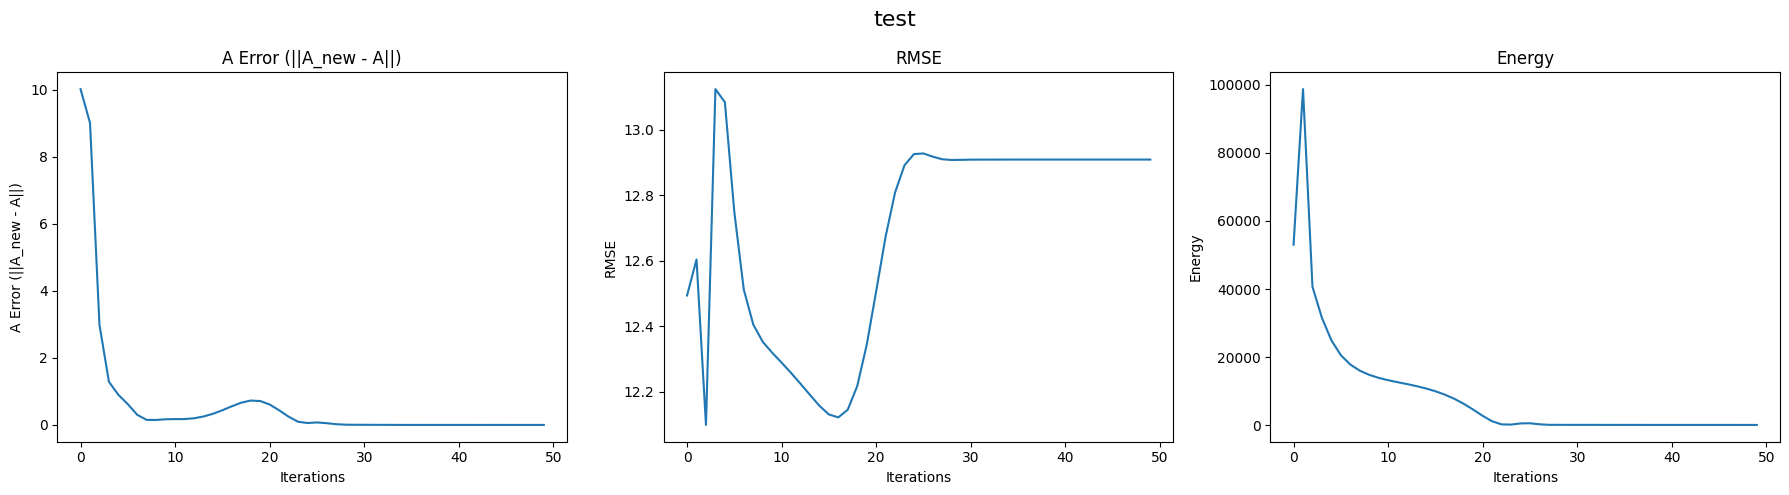

Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 12.90955001041893
Final Endmember SAD: 12.976767234427701


In [77]:
# Graph ALMM
samples = 2500
alpha = 5.5e-5
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
A_f_graph_almm, S_graph_almm, A_graph_almm_rmse, S_graph_almm_sad = run_unmixing_pipeline_example2_test(X = X_0, A_gt = A_0, S_gt = S_0, 
                                                                                                        N = samples, alpha = alpha, beta = beta, gamma = gamma, eta = eta, maxIter = 50, 
                                                                                                        M_total_0 = int(0.004*2*samples), m_0 = 4, xi_0 = 1e-3, 
                                                                                                        OH_labels = True, print_bool = True, A_error = True, RMSE_plot = True, Energy_plot = True, title_0 = "test")

# Chem Data

In [ ]:
# Subsample for faster parameter testing
N_full = X_chem.shape[1]  # total number of samples
N_sub = 500  # or whatever smaller size you want to test with

np.random.seed(42)
idx = np.random.choice(N_full, N_sub, replace=False)

X_chem_sub = X_chem[:, idx]
A_gt_chem_sub = A_gt_chem[:, idx]

In [3]:
X_chem, S_gt_chem, A_gt_chem = load_data(name = 'synth_chem_data.npy', typename = 'chem')

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (Chemistry Sample): (1000, 1000)
Shape of A_gt (Abundance Map): (2, 1000)
Shape of S_gt (Endmember Spectra): (1000, 2)

First chemical's concentration in X (how much of class 1?):
 1.1670295769786863
<class 'numpy.ndarray'>
(1000, 2)
float64
<class 'numpy.ndarray'>
(2, 1000)
float64
Shape of X: (1000, 1000)


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...


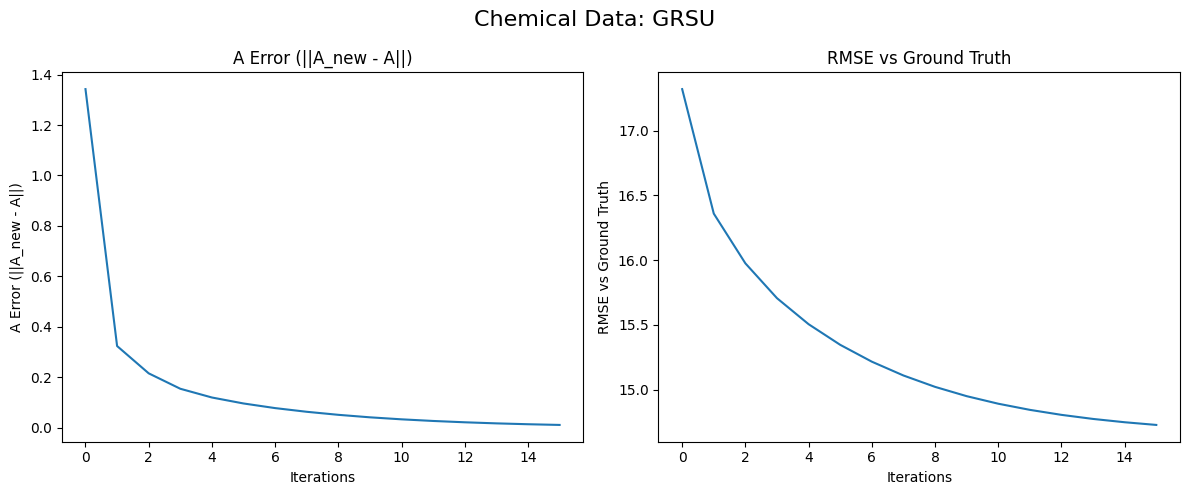

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 14.710649471862888
Final Endmember SAD: 23.453336702298987


In [ ]:
# GRSU
iters = 50
samples = 1000
# Parameters from previous testing
alpha_0 = 0.055
lam_0 = 1000
gamma_0 = 100.0
rho_0 = 100.0

# Run on best parameters
A_f_chem_GRSU, S_f_chem_GRSU, A_rmse_chem_GRSU, S_sad_chem_GRSU = run_unmixing_pipeline_example_grsu(X_chem, A_gt_chem, S_gt_chem, N = samples, iters = iters,
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, OH_labels = False, GRSU_bool = True, A_error = True, RMSE_plot = True, 
                                                        title_0 = "Chemical Data: GRSU")

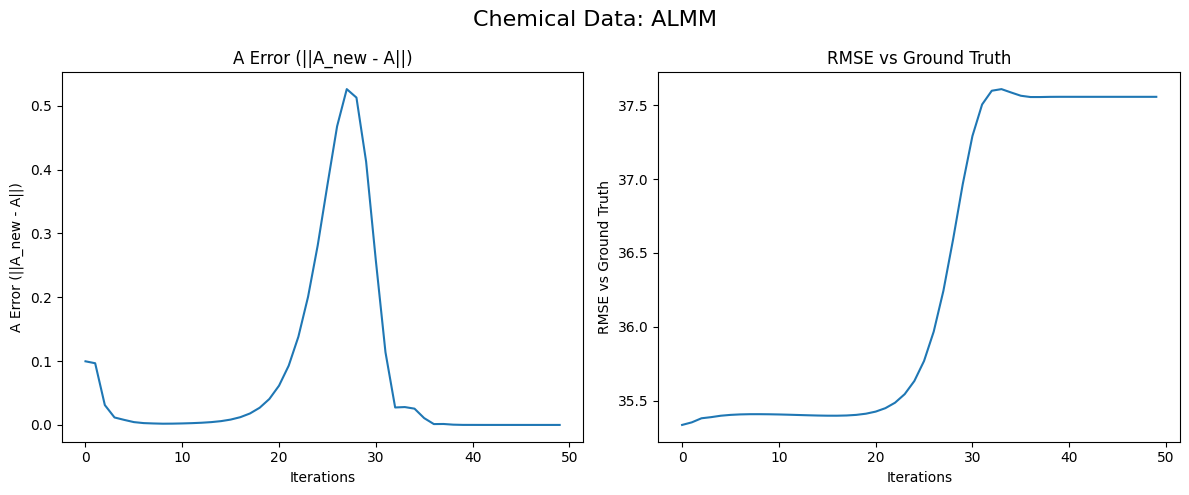

In [ ]:
# ALMM
alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2

# Pick the best alpha
best_rmse = np.inf
best_alpha = 1e-6
E_f_chem_ALMM, A_f_chem_ALMM, T_f_chem_ALMM, B_f_chem_ALMM = algo_2_almm_optimized_error(X_chem, S_gt_chem, A_gt = A_gt_chem, 
                                                                                   alpha = best_alpha, beta = beta, gamma = gamma, eta = eta, maxIter = iters,
                                                                                   A_error = True, RMSE_plot = True,
                                                                                   title_0 = "Chemical Data: ALMM")

In [4]:
# ALMM-GLU

alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
iters = 20 # changed from 50
samples = 500

# Pick the best alpha
#run_unmixing_pipeline_example2(X_chem, A_gt_chem, S_gt_chem, samples, a, beta, gamma, eta, maxIter = iters, M_total_0 = int(0.004*2*samples), m_0 = 2, print_bool = False)
best_rmse = np.inf
best_alpha = None

alpha_vals = [alpha, alpha/10, alpha/100, alpha/1000, alpha/10000]

for a in alpha_vals:

    A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example_graph_almm(X_chem_sub, A_gt_chem_sub, S_gt_chem, 
                                                                                     samples, a, beta, gamma, eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*5*samples), m_0 = 2, xi_0 = 1e-2, 
                                                                                     OH_labels = True, print_bool = False, A_error = False, RMSE_plot = False,
                                                                                     title_0 = "Chemical Data: Graph ALMM (A with OH labels, default samples, xi = 1e-1)")


    print(f"alpha={a:.6f} -> RMSE={A_rmse:.4f}, SAD={S_sad:.4f}")

    if A_rmse < best_rmse:
        best_rmse = A_rmse
        best_alpha = a

print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}, SAD: {S_sad}")

NameError: name 'run_unmixing_pipeline_example_graph_almm' is not defined

Test: A with OH labels, default samples, xi = 1e-1
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on OH...


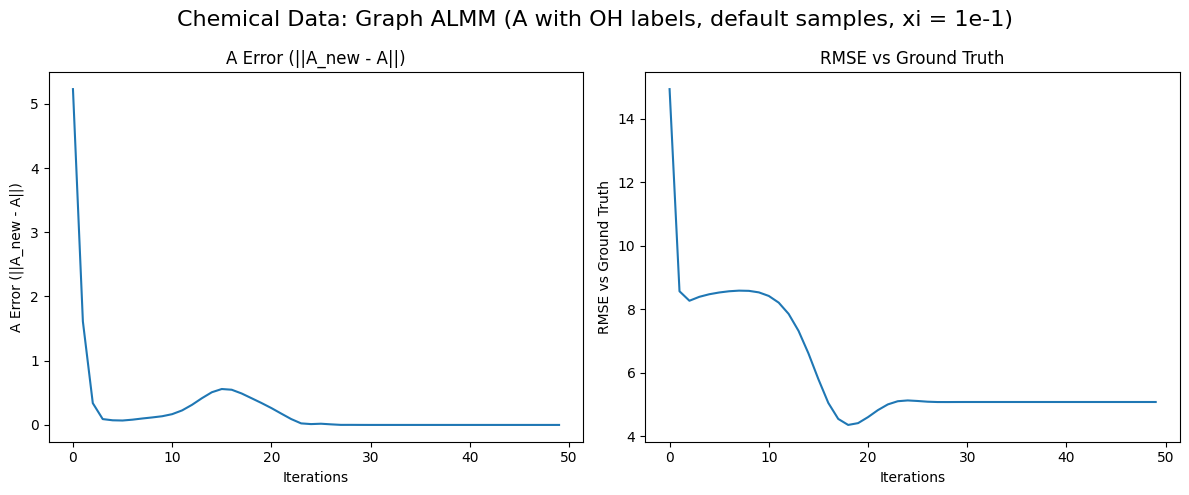

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1000, 2)
Final Abundance RMSE: 5.084647303331198
Final Endmember SAD: 32.072756773718346


In [5]:
# ALMM-GLU

alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
iters = 50 # changed from 50
samples = 1000

# Pick the best alpha
# best_rmse = np.inf
best_alpha = 1e-7

# Test: A with OH labels, default samples, xi = 1e-1
# maxIter=10 -> RMSE=9.0805
# maxIter=15 -> RMSE=6.3223
# maxIter=20 -> RMSE=3.4021
# maxIter=25 -> RMSE=3.5662
# maxIter=30 -> RMSE=3.5427
# maxIter=40 -> RMSE=3.5426
# maxIter=50 -> RMSE=3.5426

# RMSE
# 3.5425320610060456 (100 iterations)
# 3.5424986711323525 (150 iterations)

print(f"Test: A with OH labels, default samples, xi = 1e-1")
A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example2(X = X_chem, A_gt = A_gt_chem, S_gt = S_gt_chem, 
                                                                                     N = samples, alpha = best_alpha, beta = beta, gamma = gamma, eta = eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*4*samples), m_0 = 2, xi_0 = 1e-1, 
                                                                                     OH_labels = True, print_bool = True, A_error = True, RMSE_plot = True,
                                                                                     title_0 = "Chemical Data: Graph ALMM (A with OH labels, default samples, xi = 1e-1)")



Test: A with Exact labels, default samples, xi = 1e-1
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on Exact...


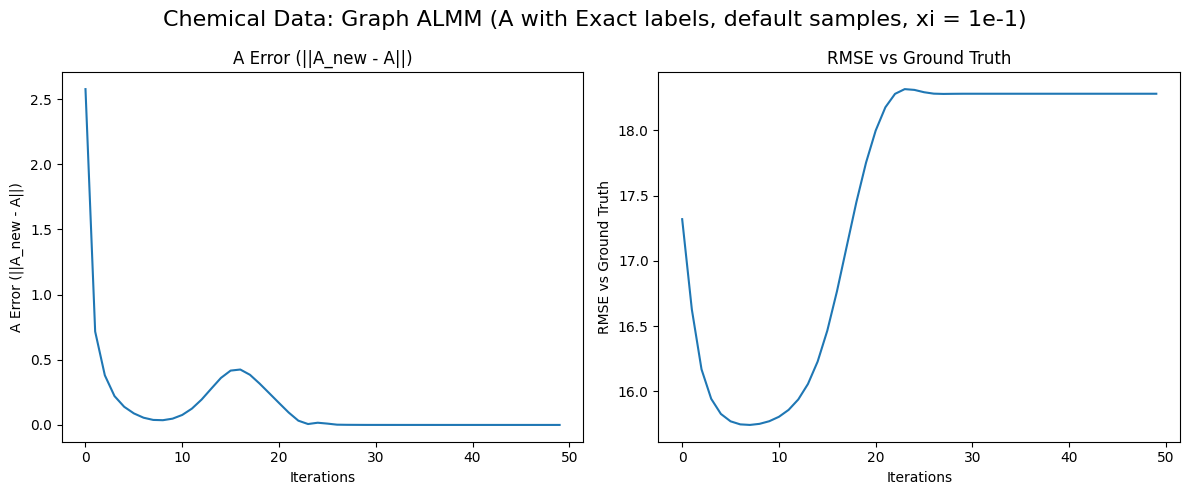

Pipeline Complete!

Final Abundance Map Shape: (2, 1000)
Final End-member Matrix Shape: (1050, 2)
Final Abundance RMSE: 18.28079531005721
Final Endmember SAD: 19.357309640619775


In [ ]:
print(f"Test: A with Exact labels, default samples, xi = 1e-1")
A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example_graph_almm(X_chem, A_gt_chem, S_gt_chem, 
                                                                                     samples, best_alpha, beta, gamma, eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*samples), m_0 = 2, xi_0 = 1e-1, 
                                                                                     OH_labels = False, print_bool = True, A_error = True, RMSE_plot = True,
                                                                                     title_0 = "Chemical Data: Graph ALMM (A with Exact labels, default samples, xi = 1e-1)")


# Nonlinear Data

In [ ]:
X_nl_flat, S_gt_nl, A_gt_nl = load_data(name = 'my_custom_dataset.npy', typename = 'nonlinear')

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (10, 250, 30)
Shape of A_gt (Abundance Map): (2, 2500)
Shape of S_gt (Endmember Spectra): (30, 2)

First pixel's spectra in X:
 [0.53910909 0.46784716 0.51651596 0.51511246 0.54243879 0.52064358
 0.51943605 0.52593777 0.53434579 0.51118315 0.51952582 0.45491021
 0.48604329 0.50390983 0.47451358 0.48900189 0.55472187 0.53542633
 0.46566486 0.46165341 0.51478674 0.51466119 0.51180038 0.5016153
 0.53460008 0.47453781 0.47549698 0.51345648 0.47629452 0.53555711]
(30, 2500)
<class 'numpy.ndarray'>
(30, 2)
float64
<class 'numpy.ndarray'>
(2, 2500)
float64
Shape of X: (30, 2500)


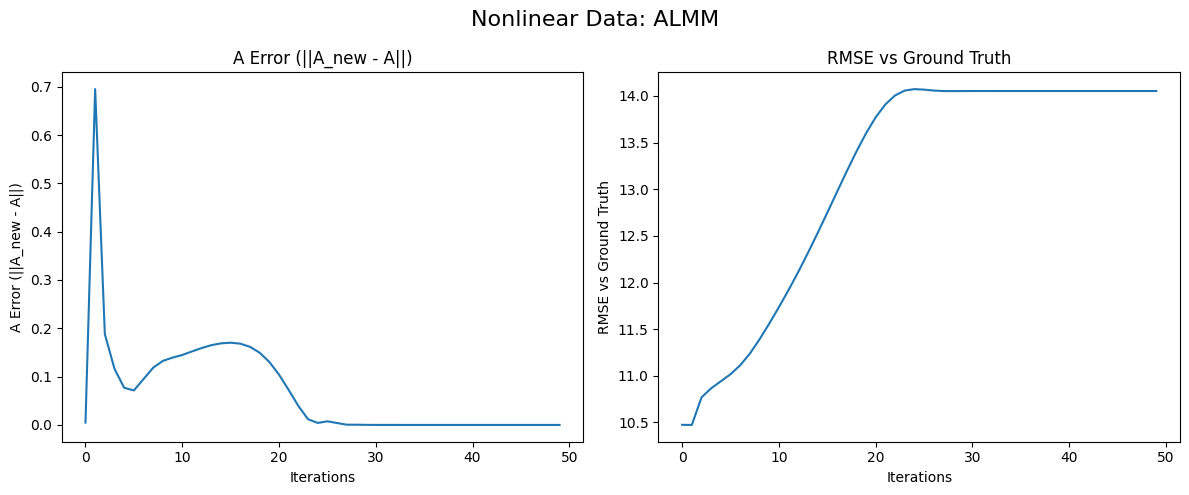

In [ ]:
# ALMM
alpha = 2e-5 # I think this was from a previous test
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2

E_f_chem_ALMM, A_f_chem_ALMM, T_f_chem_ALMM, B_f_chem_ALMM = algo_2_almm_optimized_error(X_nl_flat, S_gt_nl, A_gt = A_gt_nl, 
                                                                                   alpha = alpha, beta = beta, gamma = gamma, eta = eta, maxIter = iters,
                                                                                   A_error = True, RMSE_plot = True,
                                                                                   title_0 = "Nonlinear Data: ALMM")

In [ ]:
# ALMM-GLU
alpha = (1e-3 + 1e-2)/2
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
iters = 20 # changed from 50
samples = 2500

best_rmse = np.inf
best_alpha = None

alpha_vals = [alpha, alpha/10, alpha/100, alpha/1000, alpha/10000]

for a in alpha_vals:

    A_f_nl_ALMM_GLU, S_f, A_rmse, S_sad = run_unmixing_pipeline_example2(X_nl_flat, A_gt_nl, S_gt_nl, samples, a, beta, gamma, eta, maxIter = iters, M_total_0 = int(0.004*2*samples),  m_0 = 2, xi_0 = 1e-2, OH_labels = False, print_bool = False)

    # Check for labeling issues
    corr = np.corrcoef(A_f_nl_ALMM_GLU[0], A_gt_nl[0])[0, 1]
    if corr < 0:
        A_f_corrected = 1 - A_f_nl_ALMM_GLU
    else:
        A_f_corrected = A_f_nl_ALMM_GLU

    rmse = RMSE(A_f_corrected, A_gt_nl)  # Calculate RMSE
    print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a

print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")

# Best alpha: 5.4999999999999995e-05, RMSE: 0.9883
# Testing: A with exact labels, double samples, xi = 1e-2
# maxIter=10 -> RMSE=0.5594
# maxIter=15 -> RMSE=0.8861
# maxIter=20 -> RMSE=0.9883
# maxIter=25 -> RMSE=0.9724
# maxIter=30 -> RMSE=0.9708
# maxIter=40 -> RMSE=0.9706
# maxIter=50 -> RMSE=0.9706


alpha=0.005500 -> RMSE=7.3371
alpha=0.000550 -> RMSE=1.0398
alpha=0.000055 -> RMSE=0.9883
alpha=0.000005 -> RMSE=0.9983
alpha=0.000001 -> RMSE=0.9993

Best alpha: 5.4999999999999995e-05, RMSE: 0.9883


Test: A with exact labels, double samples, xi = 1e-2
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on Exact...


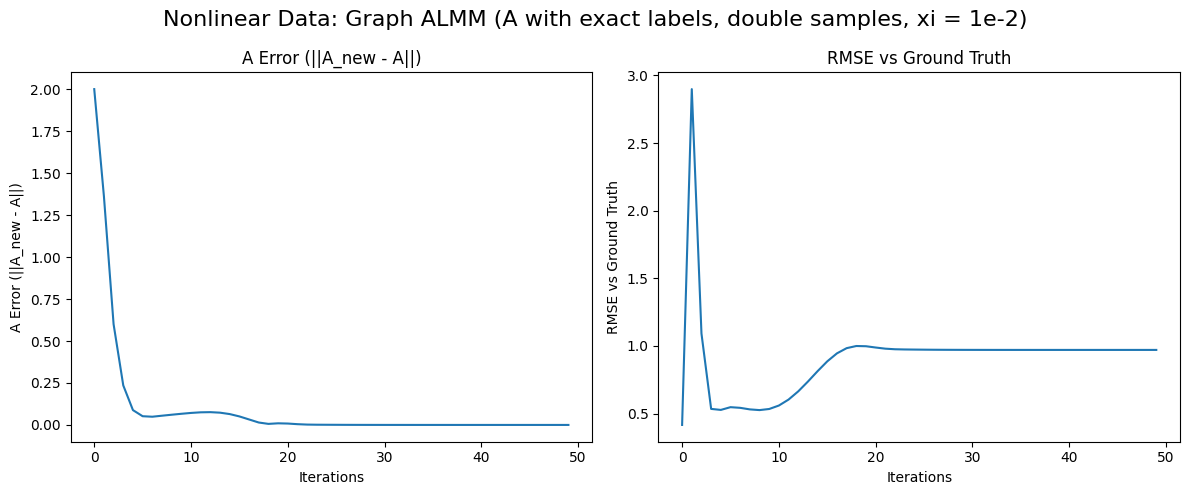

Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 0.9705617464589147
Final Endmember SAD: 18.77325030915321


In [ ]:
iters = 50
# 0.9705617464589147
print(f"Test: A with exact labels, double samples, xi = 1e-2")
A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example_graph_almm(X_nl_flat, A_gt_nl, S_gt_nl, 
                                                                                     samples, best_alpha, beta, gamma, eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*2*samples), m_0 = 2, xi_0 = 1e-2, 
                                                                                     OH_labels = False, print_bool = True, A_error = True, RMSE_plot = True,
                                                                                     title_0 = "Nonlinear Data: Graph ALMM (A with exact labels, double samples, xi = 1e-2)")


Test: A with OH labels, double samples, xi = 1e-2
Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running ALMM (and GLU) Unmixing on OH...


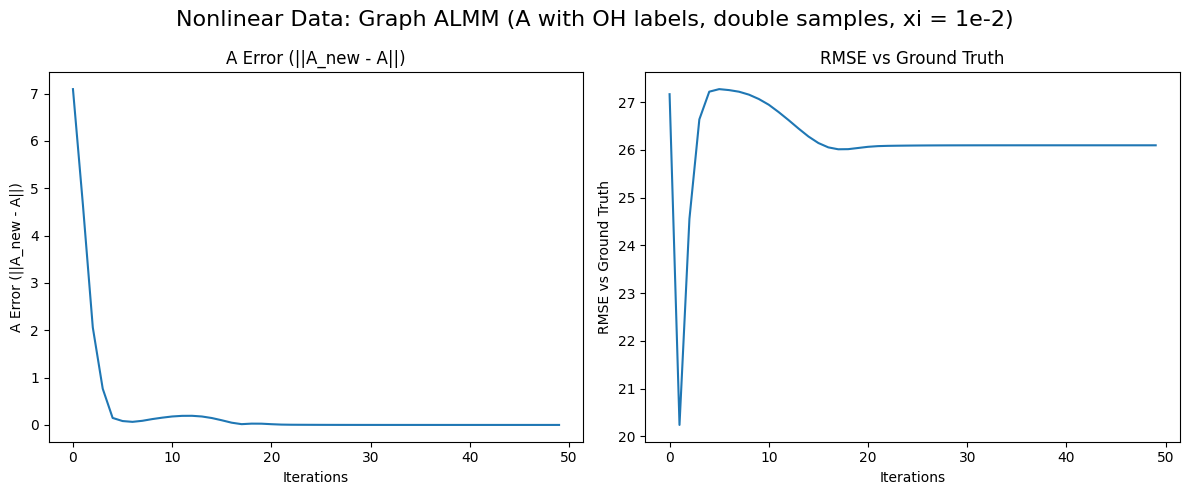

Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 26.096665156355964
Final Endmember SAD: 15.496125371750468


In [ ]:
print(f"Test: A with OH labels, double samples, xi = 1e-2")
A_f_chem_ALMM_GLU, S_f_chem_ALMM_GLU, A_rmse, S_sad = run_unmixing_pipeline_example_graph_almm(X_nl_flat, A_gt_nl, S_gt_nl, 
                                                                                     samples, best_alpha, beta, gamma, eta, maxIter = iters, 
                                                                                     M_total_0 = int(0.004*2*samples), m_0 = 2, xi_0 = 1e-2, 
                                                                                     OH_labels = True, print_bool = True, A_error = True, RMSE_plot = True,
                                                                                     title_0 = "Nonlinear Data: Graph ALMM (A with OH labels, double samples, xi = 1e-2)")
